<a href="https://colab.research.google.com/github/bgittel/Evaluative-Text-Structures/blob/main/clustering_annotation_corpus_assertive_force.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from statsmodels.stats.inter_rater import fleiss_kappa
!pip install krippendorff


Mounted at /content/drive


# Load assertion anno

In [169]:
import pandas as pd
import numpy as np
import krippendorff

# Load data from Excel files
file_path1 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Metadaten_assertiveStärke_Klarheit_BG_35.xlsx'
df_anno_BG = pd.read_excel(file_path1)
file_path2 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Metadaten_assertiveStärke_Klarheit_FS_35.xlsx'
df_anno_FS = pd.read_excel(file_path2)
file_path3 = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Metadaten_assertiveStärke_Klarheit_MA_35.xlsx'
df_anno_MA = pd.read_excel(file_path3)

# Merge the DataFrames in two steps
df_assertion = pd.merge(df_anno_BG, df_anno_MA, on='Document_title', how='inner')
df_assertion = pd.merge(df_assertion, df_anno_FS, on='Document_title', how='inner')

"""
#RENAMING OF DOC TITLES
df_assertion["Document_title"] = df_assertion["Document_title"].apply(lambda x:
    "Kafka_Der_neue_Advokat" if x == "Der neue Advokat" else
    "Kafka_Ein_Bericht_für_eine_Akademie" if x == "Ein Bericht für eine Akademie" else x
)

# Replace wrong filenames
df_assertion.loc[df_assertion["Document_title"] == "Hesse_Der Steppenwolf (annotierter Auszug!)", "Document_title"] = "Hesse_Der_Steppenwolf_Beginn.txt"

# Replace "_clean.txt" and ".txt" in the Document_title column
df_assertion["Document_title"] = df_assertion["Document_title"].str.replace("_clean.txt", "", regex=False)
df_assertion["Document_title"] = df_assertion["Document_title"].str.replace(".txt", "", regex=False)


"""

# Drop the first row
df_assertion = df_assertion.iloc[1:]

# Calculate means for specified columns
columns_to_average = {
    'implicit_assertion_mean': ['implicit_assertion_x', 'implicit_assertion_y', 'implicit_assertion'],
    'assertive_force_mean': ['assertive_force_x', 'assertive_force_y', 'assertive_force'],
    'assertive_clarity_mean': ['assertive_clarity_x', 'assertive_clarity_y', 'assertive_clarity']
}

for new_col, cols in columns_to_average.items():
    df_assertion[new_col] = df_assertion[cols].mean(axis=1)

# Define column groups for Krippendorff's Alpha calculation
column_groups = {
    'implicit_assertion': ['implicit_assertion_x', 'implicit_assertion_y', 'implicit_assertion'],
    'assertive_force': ['assertive_force_x', 'assertive_force_y', 'assertive_force'],
    'assertive_clarity': ['assertive_clarity_x', 'assertive_clarity_y', 'assertive_clarity']
}

# Function to calculate Krippendorff's Alpha for ordinal scales
def calculate_krippendorff_alpha_for_group(df, columns):
    # Get ratings data
    ratings = df[columns].astype(float).values.T  # Transpose to make each row a rater for Krippendorff's Alpha
    print(ratings)
    return krippendorff.alpha(reliability_data=ratings, level_of_measurement='ordinal')

# Calculate Krippendorff's Alpha for each group of columns
alpha_results = {}
for group_name, cols in column_groups.items():
    try:
        alpha_results[group_name] = calculate_krippendorff_alpha_for_group(df_assertion, cols)
    except ValueError as e:
        alpha_results[group_name] = str(e)

# Display the Krippendorff's Alpha results
print("\nKrippendorff's Alpha Results:")
for group_name, alpha in alpha_results.items():
    print(f"{group_name}: {alpha}")

df_assertion


[[2. 5. 1. 2. 1. 4. 1. 1. 1. 3. 4. 1. 1. 1. 1. 3. 3. 1. 1. 1. 1. 2. 3. 2.
  1. 2. 3. 4. 5. 4. 1. 1. 5. 5. 2.]
 [1. 1. 1. 3. 2. 1. 2. 1. 1. 2. 4. 2. 3. 1. 1. 1. 2. 4. 1. 2. 4. 1. 1. 3.
  1. 3. 4. 5. 1. 5. 2. 1. 5. 2. 1.]
 [1. 5. 1. 3. 2. 5. 1. 1. 2. 2. 5. 1. 2. 1. 5. 5. 5. 1. 5. 1. 3. 2. 1. 1.
  1. 2. 1. 5. 3. 5. 1. 1. 5. 5. 3.]]
[[ 9.  0. 10.  6. 10.  2. 10. 10.  8.  5.  2. 10. 10. 10. 10.  5.  5.  7.
   9. 10.  9.  8.  5.  9. 10.  5.  7.  3.  0.  1.  7. 10.  0.  1.  9.]
 [10.  9. 10.  4.  8. 10.  9.  9.  6.  6.  2. 10.  6. 10.  8. 10.  8.  6.
  10.  6.  3. 10.  8.  4. 10.  3.  2.  0. 10.  0.  6. 10.  0.  7.  8.]
 [ 9.  0. 10.  5.  8.  0. 10. 10.  7.  7.  0. 10.  8. 10.  0.  0.  0. 10.
   0.  9.  7.  8.  8.  8. 10.  6.  9.  0.  2.  0. 10. 10.  0.  0.  7.]]
[[ 6.  1.  8.  6.  7.  1. 10.  8.  1.  2.  3.  8.  8. 10.  9.  5.  2.  7.
   5.  8.  5.  6.  4.  2. 10.  6.  3.  2.  0.  0.  7.  9.  0.  0.  7.]
 [ 9.  8. 10.  4.  7. 10.  7.  6.  6.  6.  2.  9.  6. 10.  8. 10.  6.  9.
   7.  6.  3. 

,Document_title,implicit_assertion_x,assertive_force_x,assertive_clarity_x,guess_implicit_assertion_x,implicit_assertion_y,assertive_force_y,assertive_clarity_y,guess_implicit_assertion_y,implicit_assertion,assertive_force,assertive_clarity,guess_implicit_assertion,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean
1,Aichinger_Das_Fenstertheater.txt,2,9,6,NaN,1,10,9,Man sollte andere nicht verurteilen und sich n...,1,9,9,"man soll andere ihr Leben leben lassen, wie si...",1.333333,9.333333,8.0
2,Altenberg_Die_Natur.txt,5,0,1,NaN,1,9,8,"Wo der Mensch ist, herrscht Leid, und die unbe...",5,0,0,NaN,3.666667,3.0,3.0
3,Auerbach_Der_Kindesmord.txt,1,10,8,NaN,1,10,10,Man sollte Ammen bessere Arbeitsbedingungen bi...,1,10,10,Ammen und deren Kinder sollen nicht ausgenutzt...,1.0,10.0,9.333333
4,Bachmann_Arkadien_clean_neu.txt,2,6,6,NaN,3,4,4,"Die Sehnsucht nach der Heimat bleibt, auch wen...",3,5,5,Stadtleben und Arbeit halten von Natur fern,2.666667,5.0,5.0
5,Bierbaum_Der_Mohr.txt,1,10,7,NaN,2,8,7,"Man sollte sich nicht gegenseitig bekämpfen, s...",2,8,5,der Friede zwischen den Nationen (Deutschland ...,1.666667,8.666667,6.333333
6,Bobrowski_Brief_aus_Amerika.txt,4,2,1,NaN,1,10,10,Kluft zwischen den älteren und den jüngeren Ge...,5,0,0,NaN,3.333333,4.0,3.666667
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,1,10,10,NaN,2,9,7,Verfall der Gesellschaft und der Kultur,1,10,9,Krieg ist das Gegenteil von Kultur,1.333333,9.666667,8.666667
8,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,1,10,8,NaN,1,9,6,Reiche Menschen stehlen,1,10,10,reich sein heißt seinen Reichtum gestohlen zu ...,1.0,9.666667,8.0
9,Brecht_Müllers_natürliche_Haltung.txt,1,8,1,NaN,1,6,6,Hinterfragen von Fortschritt ist gut und richt...,2,7,7,"dem Fortschritt zu misstrauen heißt nicht, das...",1.333333,7.0,4.666667
10,Dorn_Vorsicht_Steinschlag.txt,3,5,2,NaN,2,6,6,Machtverhältnisse zwischen den Geschlechtern,2,7,5,"auch große, mächtige Männer können fallen",2.333333,6.0,4.333333


In [170]:
# select mean cols for clustering

df_assertion = df_assertion[["Document_title", "implicit_assertion_mean",	"assertive_force_mean",	"assertive_clarity_mean"]]

# Define category boundaries and labels based on the scale:
# Adjust intervals as needed to best fit the means in your data.
"""bins = [0.99, 1.5, 2.5, 3.5, 4.5, 5.0]  # Define bin edges for ranges
labels = [
    'trifft zu',            # 1
    'trifft eher zu',       # 2
    'teils-teils',          # 3
    'trifft eher nicht zu', # 4
    'trifft nicht zu'       # 5
]
"""

bins = [0.99, 3, 5.0]  # Define bin edges for ranges
labels = [
    'IA',            # 1
    'NO-IA'       # 5
]

# Use pd.cut to categorize based on defined bins and labels
df_assertion['implicit_assertion_cat'] = pd.cut(
    df_assertion['implicit_assertion_mean'],
    bins=bins,
    labels=labels,
    right=True  # Include the right edge in each bin interval
)

bins = [-1, 5, 11]  # Define bin edges for ranges
labels = [
    'LOW',
    'HIGH'
]

bins2 = [-1, 5, 11]  # Define bin edges for ranges
labels2 = [
    'LOW',
    'HIGH'
]

# Use pd.cut to categorize based on defined bins and labels
df_assertion['assertive_clarity_cat'] = pd.cut(
    df_assertion['assertive_clarity_mean'],
    bins=bins,
    labels=labels,
    right=True  # Include the right edge in each bin interval
)

# Use pd.cut to categorize based on defined bins and labels
df_assertion['assertive_force_cat'] = pd.cut(
    df_assertion['assertive_force_mean'],
    bins=bins2,
    labels=labels2,
    right=True  # Include the right edge in each bin interval
)

df_assertion

/tmp/ipython-input-170-1031896817.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_assertion['implicit_assertion_cat'] = pd.cut(
/tmp/ipython-input-170-1031896817.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_assertion['assertive_clarity_cat'] = pd.cut(
/tmp/ipython-input-170-1031896817.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

,Document_title,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean,implicit_assertion_cat,assertive_clarity_cat,assertive_force_cat
1,Aichinger_Das_Fenstertheater.txt,1.333333,9.333333,8.0,IA,HIGH,HIGH
2,Altenberg_Die_Natur.txt,3.666667,3.0,3.0,NO-IA,LOW,LOW
3,Auerbach_Der_Kindesmord.txt,1.0,10.0,9.333333,IA,HIGH,HIGH
4,Bachmann_Arkadien_clean_neu.txt,2.666667,5.0,5.0,IA,LOW,LOW
5,Bierbaum_Der_Mohr.txt,1.666667,8.666667,6.333333,IA,HIGH,HIGH
6,Bobrowski_Brief_aus_Amerika.txt,3.333333,4.0,3.666667,NO-IA,LOW,LOW
7,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,1.333333,9.666667,8.666667,IA,HIGH,HIGH
8,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,1.0,9.666667,8.0,IA,HIGH,HIGH
9,Brecht_Müllers_natürliche_Haltung.txt,1.333333,7.0,4.666667,IA,LOW,HIGH
10,Dorn_Vorsicht_Steinschlag.txt,2.333333,6.0,4.333333,IA,LOW,HIGH


In [171]:
len(df_assertion)

35

# Load annotation overview scheme

In [172]:
# Step 2: Read the Excel file from Google Drive
file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/02_annotation_overview_scheme_20250527.xlsx'
#file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/02_annotation_overview_scheme_20241219.csv'

df_summary = pd.read_excel(file_path)
#df_summary['Document_title'] = df_summary['Document_title'].astype(str) + '.txt'

print(len(df_summary))
#print(df_summary)
#file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/04_summary_statistics_20240930_183449.xlsx'
#df_summary = pd.read_excel(file_path)

# Merge the DataFrames based on 'document_title'
#df = pd.merge(df_anno, df_summary, on='Document_title', how='inner')  # Change 'inner' to 'left', 'right', or 'outer' as needed
#df = df_anno

file_path = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/Übersicht_Annotexte_AKTUELL_35.xlsx'
df_metadata = pd.read_excel(file_path)
df_metadata = df_metadata[["Document_title", "Typ"]]

"""
#RENAMING OF DOC TITLES
df_metadata["Document_title"] = df_metadata["Document_title"].apply(lambda x:
    "Kafka_Der_neue_Advokat" if x == "Der neue Advokat" else
    "Kafka_Ein_Bericht_für_eine_Akademie" if x == "Ein Bericht für eine Akademie" else x
)
"""
# Replace "_clean.txt" and ".txt" in the Document_title column
#df_metadata["Document_title"] = df_metadata["Document_title"].str.replace("_clean.txt", "", regex=False)
#df_metadata["Document_title"] = df_metadata["Document_title"].str.replace(".txt", "", regex=False)



# Merge the DataFrames based on 'document_title'
df = pd.merge(df_summary, df_metadata, on='Document_title', how='inner')

# Merge the DataFrames based on 'document_title'
df = pd.merge(df, df_assertion, on='Document_title', how='inner')


#df = df.iloc[2:25, :]

#df = df.convert_dtypes()
print(len(df_metadata))
print(len(df_assertion))
print(len(df))
df.head(5)


35
35
35
35


,Document_title,Textlänge_token,Textlänge_sent,Entität_gesamt,Entität_Ding,Entität_Figur,Entität_Figurengruppe,Entität_Raum,Entität_Bereich,Entität_Grenze,Entität_Zeitabschnitt,Entität_Sonstige,Wertung_gesamt,Erzählerwertung,Figurenwertung,Wertung_Kompositionsebene,positive_Wertung,negative_Wertung,positive_Wertung_mit_Ironie,negative_Wertung_mit_Ironie,Wertung_moralisch,Wertung_eudämonistisch,Wertung_sozialer_Status,Wertung_ästhetisch,Wertung_sonstige,Wertung_eudämonistisch_figure,Wertung_eudämonistisch_not_figure,NP_Wertung,Teilsatzwertung,Codierung_gesamt,Codierung_tief_oberflächlich,Codierung_natürlich_kulturell,Codierung_traditionell_modern,Codierung_harmonisch_disharmonisch,Codierung_Gesund_krank,Opposition_gesamt,Wertopposition,Wertopposition_Oppositionspaar,Traditionell-modern-Opposition,Harmonisch-disharmonisch-Opposition,Natürlich-kulturell-Opposition,Gesund-krank-Opposition,Tiefgründig-oberflächlich-Opposition,Sonstige_Merkmalsopposition,Merkmalsopposition_Oppositionspaar,Zugehörigkeit_zu,Element_von,Span_FIGUR,Span_LISTE_FIGUR,Span_RAUM,Span_LISTE_RAUM,Span_DING,Span_LISTE_DING,Span_SONSTIGE,Span_LISTE_SONSTIGE,Span_FIGURENGRUPPE,Span_LISTE_FIGURENGRUPPE,Span_BEREICH,Span_LISTE_BEREICH,Span_GRENZE,Span_LISTE_GRENZE,Span_ABSTRAKTUM,Span_LISTE_ABSTRAKTUM,Span_ZEITABSCHNITT,Span_LISTE_ZEITABSCHNITT,Span_ORGANISATION,Span_LISTE_ORGANISATION,Span_NONE,Span_LISTE_NONE,Span_entities_with_Referenz_Wikidata,Span_LISTE_entities_with_Referenz_Wikidata,total_list_naming_mistakes,list_naming_mistakes,Erzählerwechsel,Kritikhaltige_Reflexion,TriggerCodierung,TriggerWertung,TriggerMerkmalsopposition,Overlapping_Oppositions,Span_LISTE_Overlapping_Oppositions,evaluative_difference_of_contrastive_entities,codierung_with_trigger_explicit,codierung_without_trigger_implicit,wertung_with_trigger_explicit,wertung_without_trigger_implicit,ratio_explicit_implicit_codierung,ratio_explicit_implicit_wertung,Typ,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean,implicit_assertion_cat,assertive_clarity_cat,assertive_force_cat
0,Aichinger_Das_Fenstertheater.txt,911,61,32,7,18,3,1,0,0,0,3,22,17,5,1,6,18,0,0,3,5,0,0,12,0,5,0,0,6,0,0,3,2,1,6,0,-,1,1,0,0,0,4,verbittert vs. lebensfroh;hell vs. finster;hel...,3,0,3,aichinger: die frau;aichinger: der alte;aichin...,1,aichinger: die straße;,7,aichinger: dieses licht;aichinger: aufflammend...,3,aichinger: der wind;aichinger: ihre erklärung;...,3,aichinger: eine menschenmenge;aichinger: die p...,0,-,0,-,0,-,0,-,0,-,0,-,0,-,0,NaN,1,0,6,13,3,2,{'Aichinger: Die Frau': {'Aichinger: der Alte'...,0.052632,4,2,15,7,2.000000,2.142857,feature contrast & value contrast,1.333333,9.333333,8.0,IA,HIGH,HIGH
1,Altenberg_Die_Natur.txt,534,24,23,2,12,1,5,1,0,0,2,8,2,6,0,6,1,0,0,1,1,0,4,2,0,1,0,0,13,0,5,0,6,2,6,0,-,0,1,3,0,0,2,zusammen vs. allein;zusammen vs. allein;,0,0,4,altenberg: er;altenberg: das fräulein;altenber...,5,altenberg: den grauen cyclopischen quai-mauern...,1,altenberg: lila seide;,2,altenberg: dem spaziergang;altenberg: eine ste...,1,altenberg: zwei blühende kinder;,1,altenberg: das ufer;,0,-,0,-,0,-,0,-,0,-,0,-,0,NaN,1,0,27,10,0,0,{},0.000000,12,1,8,0,12.000000,0.000000,-,3.666667,3.0,3.0,NO-IA,LOW,LOW
2,Auerbach_Der_Kindesmord.txt,4932,249,217,10,127,33,3,0,0,4,40,199,131,68,0,97,115,7,3,46,54,11,9,77,6,48,0,0,30,5,4,4,8,9,11,2,gebildet vs. vorurteilsreich;moralisch;,0,0,0,1,0,8,kindlich vs. militärisch;reich vs. arm;arm vs....,2,0,29,auerbach: der jüngste;auerbach: der andere;aue...,2,"auerbach: amerika;auerbach: feuchte, enge stra...",9,auerbach: kinderzeug von weichem linnen;auerba...,37,auerbach: den donaumündungen;auerbach: die gan...,21,auerbach: so vieler menschen;auerbach: ein woh...,0,-,0,-,6,auerbach: die wahrheit;auerbach: der weltgeist...,3,auerbach: der schweren stunde;auerbach: eine n...,3,auerbach: der verein gegen tierquälerei;auerba...,0,-,3,http://www.wikidata.org/entity/Q1653;http://ww...,3,auerbach: anton1 vs auerbach: anton2;auerbach:...,3,6,21,202,10,5,{'Auerbach: A

In [173]:
# Values in df_assertion not in df_metadata
only_in_assertion = set(df_assertion['Document_title']) - set(df['Document_title'])

# Values in df_metadata not in df_assertion
only_in_metadata = set(df_metadata['Document_title']) - set(df_assertion['Document_title'])



In [174]:
only_in_assertion

set()

In [175]:
# insert cat col at beginning
#df.insert(1, "Typ2", df["Typ"])
df.insert(1, "assertive_clarity_cat2", df["assertive_clarity_cat"])
df.insert(1, "assertive_force_cat2", df["assertive_force_cat"])
#df.drop(columns=["implizite_Assertion_Category"], inplace=True)


"""
df.insert(1, "implicit_assertion_cat2", df["implicit_assertion_cat"])
df.drop(columns=["implizite_Assertion_Category"], inplace=True)
df.drop(columns=["implicit_assertion_cat"], inplace=True)
"""
df.head(5)

,Document_title,assertive_force_cat2,assertive_clarity_cat2,Textlänge_token,Textlänge_sent,Entität_gesamt,Entität_Ding,Entität_Figur,Entität_Figurengruppe,Entität_Raum,Entität_Bereich,Entität_Grenze,Entität_Zeitabschnitt,Entität_Sonstige,Wertung_gesamt,Erzählerwertung,Figurenwertung,Wertung_Kompositionsebene,positive_Wertung,negative_Wertung,positive_Wertung_mit_Ironie,negative_Wertung_mit_Ironie,Wertung_moralisch,Wertung_eudämonistisch,Wertung_sozialer_Status,Wertung_ästhetisch,Wertung_sonstige,Wertung_eudämonistisch_figure,Wertung_eudämonistisch_not_figure,NP_Wertung,Teilsatzwertung,Codierung_gesamt,Codierung_tief_oberflächlich,Codierung_natürlich_kulturell,Codierung_traditionell_modern,Codierung_harmonisch_disharmonisch,Codierung_Gesund_krank,Opposition_gesamt,Wertopposition,Wertopposition_Oppositionspaar,Traditionell-modern-Opposition,Harmonisch-disharmonisch-Opposition,Natürlich-kulturell-Opposition,Gesund-krank-Opposition,Tiefgründig-oberflächlich-Opposition,Sonstige_Merkmalsopposition,Merkmalsopposition_Oppositionspaar,Zugehörigkeit_zu,Element_von,Span_FIGUR,Span_LISTE_FIGUR,Span_RAUM,Span_LISTE_RAUM,Span_DING,Span_LISTE_DING,Span_SONSTIGE,Span_LISTE_SONSTIGE,Span_FIGURENGRUPPE,Span_LISTE_FIGURENGRUPPE,Span_BEREICH,Span_LISTE_BEREICH,Span_GRENZE,Span_LISTE_GRENZE,Span_ABSTRAKTUM,Span_LISTE_ABSTRAKTUM,Span_ZEITABSCHNITT,Span_LISTE_ZEITABSCHNITT,Span_ORGANISATION,Span_LISTE_ORGANISATION,Span_NONE,Span_LISTE_NONE,Span_entities_with_Referenz_Wikidata,Span_LISTE_entities_with_Referenz_Wikidata,total_list_naming_mistakes,list_naming_mistakes,Erzählerwechsel,Kritikhaltige_Reflexion,TriggerCodierung,TriggerWertung,TriggerMerkmalsopposition,Overlapping_Oppositions,Span_LISTE_Overlapping_Oppositions,evaluative_difference_of_contrastive_entities,codierung_with_trigger_explicit,codierung_without_trigger_implicit,wertung_with_trigger_explicit,wertung_without_trigger_implicit,ratio_explicit_implicit_codierung,ratio_explicit_implicit_wertung,Typ,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean,implicit_assertion_cat,assertive_clarity_cat,assertive_force_cat
0,Aichinger_Das_Fenstertheater.txt,HIGH,HIGH,911,61,32,7,18,3,1,0,0,0,3,22,17,5,1,6,18,0,0,3,5,0,0,12,0,5,0,0,6,0,0,3,2,1,6,0,-,1,1,0,0,0,4,verbittert vs. lebensfroh;hell vs. finster;hel...,3,0,3,aichinger: die frau;aichinger: der alte;aichin...,1,aichinger: die straße;,7,aichinger: dieses licht;aichinger: aufflammend...,3,aichinger: der wind;aichinger: ihre erklärung;...,3,aichinger: eine menschenmenge;aichinger: die p...,0,-,0,-,0,-,0,-,0,-,0,-,0,-,0,NaN,1,0,6,13,3,2,{'Aichinger: Die Frau': {'Aichinger: der Alte'...,0.052632,4,2,15,7,2.000000,2.142857,feature contrast & value contrast,1.333333,9.333333,8.0,IA,HIGH,HIGH
1,Altenberg_Die_Natur.txt,LOW,LOW,534,24,23,2,12,1,5,1,0,0,2,8,2,6,0,6,1,0,0,1,1,0,4,2,0,1,0,0,13,0,5,0,6,2,6,0,-,0,1,3,0,0,2,zusammen vs. allein;zusammen vs. allein;,0,0,4,altenberg: er;altenberg: das fräulein;altenber...,5,altenberg: den grauen cyclopischen quai-mauern...,1,altenberg: lila seide;,2,altenberg: dem spaziergang;altenberg: eine ste...,1,altenberg: zwei blühende kinder;,1,altenberg: das ufer;,0,-,0,-,0,-,0,-,0,-,0,-,0,NaN,1,0,27,10,0,0,{},0.000000,12,1,8,0,12.000000,0.000000,-,3.666667,3.0,3.0,NO-IA,LOW,LOW
2,Auerbach_Der_Kindesmord.txt,HIGH,HIGH,4932,249,217,10,127,33,3,0,0,4,40,199,131,68,0,97,115,7,3,46,54,11,9,77,6,48,0,0,30,5,4,4,8,9,11,2,gebildet vs. vorurteilsreich;moralisch;,0,0,0,1,0,8,kindlich vs. militärisch;reich vs. arm;arm vs....,2,0,29,auerbach: der jüngste;auerbach: der andere;aue...,2,"auerbach: amerika;auerbach: feuchte, enge stra...",9,auerbach: kinderzeug von weichem linnen;auerba...,37,auerbach: den donaumündungen;auerbach: die gan...,21,auerbach: so vieler menschen;auerbach: ein woh...,0,-,0,-,6,auerbach: die wahrheit;auerbach: der weltgeist...,3,auerbach: der schweren stunde;auerbach: eine n...,3,auerbach: der verein gegen tierquälerei;auerba...,0,-,3,http://www.wikidata.org/entity/Q1653;http://ww...,3,auerbac

In [176]:
# Convert columns to float if possible, skip if they contain non-numeric data
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col], errors='raise').astype(float)
    except ValueError:
        pass  # Skip columns that cannot be converted

columns_to_keep = [col for col in df.columns if not col.startswith('Span_') and not col.startswith('Entität') or col == 'Span_entities_with_Referenz_Wikidata']

# Select only the columns to keep
df = df[columns_to_keep]
df.drop('total_list_naming_mistakes', axis=1, inplace=True)
df.drop('Textlänge_sent', axis=1, inplace=True)

# Step 3: Select the first column (non-numerical) and the numerical columns
first_cols = df.iloc[:, :5]  # Select the first column (by index)
numerical_columns = df.select_dtypes(include=['number'])  # Select only numerical columns
#cat_cols = df[["Document_title","implicit_assertion_cat"]]

# Step 4: Concatenate the first column with the numerical columns
result_df = pd.concat([first_cols, numerical_columns], axis=1)

# divide all cosl by text length (except text length)
#result_df.iloc[:,5:] = result_df.iloc[:,5:].div(result_df.Textlänge_token, axis=0)

# add info to first col
# all info
#result_df["Document_title"] = df["Document_title"] + "---" + result_df["assertive_clarity_cat2"].str.upper() + "_" + result_df["assertive_force_cat2"].str.upper()

# only assertive force
result_df["Document_title"] = df["Document_title"] + "---" + result_df["assertive_force_cat2"].str.upper()

# only assertive clarity
#result_df["Document_title"] = df["Document_title"] + "---" + result_df["assertive_clarity_cat2"].str.upper()

# Display the first few rows of the result
result_df.head(10)

,Document_title,assertive_force_cat2,assertive_clarity_cat2,Textlänge_token,Wertung_gesamt,Textlänge_token,Wertung_gesamt,Erzählerwertung,Figurenwertung,Wertung_Kompositionsebene,positive_Wertung,negative_Wertung,positive_Wertung_mit_Ironie,negative_Wertung_mit_Ironie,Wertung_moralisch,Wertung_eudämonistisch,Wertung_sozialer_Status,Wertung_ästhetisch,Wertung_sonstige,Wertung_eudämonistisch_figure,Wertung_eudämonistisch_not_figure,NP_Wertung,Teilsatzwertung,Codierung_gesamt,Codierung_tief_oberflächlich,Codierung_natürlich_kulturell,Codierung_traditionell_modern,Codierung_harmonisch_disharmonisch,Codierung_Gesund_krank,Opposition_gesamt,Wertopposition,Traditionell-modern-Opposition,Harmonisch-disharmonisch-Opposition,Natürlich-kulturell-Opposition,Gesund-krank-Opposition,Tiefgründig-oberflächlich-Opposition,Sonstige_Merkmalsopposition,Zugehörigkeit_zu,Element_von,Span_entities_with_Referenz_Wikidata,Erzählerwechsel,Kritikhaltige_Reflexion,TriggerCodierung,TriggerWertung,TriggerMerkmalsopposition,Overlapping_Oppositions,evaluative_difference_of_contrastive_entities,codierung_with_trigger_explicit,codierung_without_trigger_implicit,wertung_with_trigger_explicit,wertung_without_trigger_implicit,ratio_explicit_implicit_codierung,ratio_explicit_implicit_wertung,implicit_assertion_mean,assertive_force_mean,assertive_clarity_mean
0,Aichinger_Das_Fenstertheater.txt---HIGH,HIGH,HIGH,911.0,22.0,911.0,22.0,17.0,5.0,1.0,6.0,18.0,0.0,0.0,3.0,5.0,0.0,0.0,12.0,0.0,5.0,0.0,0.0,6.0,0.0,0.0,3.0,2.0,1.0,6.0,0.0,1.0,1.0,0.0,0.0,0.0,4.0,3.0,0.0,0.0,1.0,0.0,6.0,13.0,3.0,2.0,0.052632,4.0,2.0,15.0,7.0,2.000000,2.142857,1.333333,9.333333,8.000000
1,Altenberg_Die_Natur.txt---LOW,LOW,LOW,534.0,8.0,534.0,8.0,2.0,6.0,0.0,6.0,1.0,0.0,0.0,1.0,1.0,0.0,4.0,2.0,0.0,1.0,0.0,0.0,13.0,0.0,5.0,0.0,6.0,2.0,6.0,0.0,0.0,1.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,27.0,10.0,0.0,0.0,0.000000,12.0,1.0,8.0,0.0,12.000000,0.000000,3.666667,3.000000,3.000000
2,Auerbach_Der_Kindesmord.txt---HIGH,HIGH,HIGH,4932.0,199.0,4932.0,199.0,131.0,68.0,0.0,97.0,115.0,7.0,3.0,46.0,54.0,11.0,9.0,77.0,6.0,48.0,0.0,0.0,30.0,5.0,4.0,4.0,8.0,9.0,11.0,2.0,0.0,0.0,0.0,1.0,0.0,8.0,2.0,0.0,3.0,3.0,6.0,21.0,202.0,10.0,5.0,0.033333,15.0,15.0,167.0,32.0,1.000000,5.218750,1.000000,10.000000,9.333333
3,Bachmann_Arkadien_clean_neu.txt---LOW,LOW,LOW,922.0,23.0,922.0,23.0,23.0,0.0,0.0,13.0,7.0,0.0,0.0,2.0,5.0,2.0,2.0,12.0,0.0,5.0,0.0,0.0,15.0,0.0,10.0,3.0,2.0,0.0,4.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,33.0,22.0,0.0,0.0,0.000000,13.0,2.0,20.0,3.0,6.500000,6.666667,2.666667,5.000000,5.000000
4,Bierbaum_Der_Mohr.txt---HIGH,HIGH,HIGH,2712.0,116.0,2712.0,116.0,77.0,39.0,1.0,50.0,68.0,7.0,1.0,9.0,6.0,10.0,16.0,72.0,0.0,6.0,0.0,0.0,29.0,0.0,16.0,2.0,9.0,2.0,15.0,0.0,0.0,1.0,5.0,1.0,0.0,8.0,0.0,0.0,6.0,1.0,2.0,33.0,114.0,19.0,4.0,0.013393,23.0,6.0,104.0,12.0,3.833333,8.666667,1.666667,8.666667,6.333333
5,Bobrowski_Brief_aus_Amerika.txt---LOW,LOW,LOW,826.0,10.0,826.0,10.0,4.0,6.0,0.0,7.0,2.0,0.0,0.0,0.0,0.0,1.0,5.0,1.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0,1.0,2.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,1.0,0.0,8.0,6.0,0.0,0.0,0.000000,3.0,1.0,7.0,3.0,3.000000,2.333333,3.333333,4.000000,3.666667
6,Brecht_Herr_Keuner_und_die_Schauspielerin.txt-...,HIGH,HIGH,204.0,14.0,204.0,14.0,7.0,7.0,0.0,8.0,5.0,0.0,0.0,9.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,10.0,2.0,2.0,0.076923,1.0,1.0,12.0,2.0,1.000000,6.000000,1.000000,9.666667,8.000000
7,Brecht_Müllers_natürliche_Haltung.txt---HIGH,HIGH,LOW,2621.0,57.0,2621.0,57.0,23.0,34.0,1.0,7.0,56.0,0.0,0.0,2.0,6.0,0.0,3.0,42.0,0.0,6.0,0.0,0.0,26.0,3.0,13.0,1.0,9.0,0.0,5.0,1.0,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,5.0,8.0,2.0,10.0,47.0,5.0,3.0,0.086207,11.0,15.0,41.0,16.0,0.733333,2.562500,1.333333,7.000000,4.666667
8,Böll_Wanderer_kommst_du_nach_Spa_clean.txt---HIGH,HIGH,HIGH,3960.0,60.0,3960.0,60.0,57.0,3.0,0.0,22.0,37.0,0.0,0.0,1.0,20.0,0.0,21.0,17.0,0.0,20.0,0.0,0.0,12.0,0.0,2.0,7.0,3.0,0.0,3.0,3.0,0.0,0.0

# Filter cols

In [177]:
# create Codierungsopposition_gesamt
result_df["Codierungsopposition_gesamt"] = result_df["Traditionell-modern-Opposition"] + result_df["Harmonisch-disharmonisch-Opposition"] + result_df["Natürlich-kulturell-Opposition"] +	result_df["Gesund-krank-Opposition"]	+ result_df["Tiefgründig-oberflächlich-Opposition"]
result_df["Wertneutrale_Opposition_gesamt"] = result_df["Codierungsopposition_gesamt"] + result_df["Sonstige_Merkmalsopposition"]

# absolute values of evaluative_difference_of_contrastive_entities
result_df["evaluative_difference_of_contrastive_entities"] = result_df["evaluative_difference_of_contrastive_entities"].abs()
result_df["ratio_positive_negative_evaluations"] = result_df["positive_Wertung"]/result_df["negative_Wertung"]
result_df["ratio_narrator_character_evaluations"] = result_df["Erzählerwertung"]/result_df["Figurenwertung"]
result_df["ratio_explicit_implicit_evaluations"] = result_df["ratio_explicit_implicit_wertung"]


# english names
result_df["narrator_evaluations"] = result_df["Erzählerwertung"]
result_df["character_evaluations"] = result_df["Figurenwertung"]
result_df["evaluations_composition_level"] = result_df["Wertung_Kompositionsebene"]
result_df["value_oppositions"] = result_df["Wertopposition"]
result_df["encoding_oppositions"] = result_df["Codierungsopposition_gesamt"]
result_df["feature_oppositions"] = result_df["Sonstige_Merkmalsopposition"]
result_df["positive_evaluations"] = result_df["positive_Wertung"]
result_df["negative_evaluations"] = result_df["negative_Wertung"]
result_df["overlapping_oppositions"] = result_df["Overlapping_Oppositions"]
result_df["explicit_evaluations"] = result_df["wertung_with_trigger_explicit"]
result_df["implicit_evaluations"] = result_df["wertung_without_trigger_implicit"]




# Identify numerical columns whose names do contain 'Summary'
#cols_to_drop = [col for col in result_df.select_dtypes(include=['number']).columns if 'Summary' in col]

# Drop the identified columns
#result_df = result_df.drop(cols_to_drop, axis=1)

# Filter cols manually

cols_to_keep =["Document_title", 'assertive_clarity_cat2', 'assertive_force_cat2',
               #"ratio_positive_negative_evaluations",
               #"ratio_explicit_implicit_evaluations",
               #"ratio_narrator_character_evaluations",
               "narrator_evaluations",
               "character_evaluations",
               "evaluations_composition_level",
               "value_oppositions",
               "encoding_oppositions",
               "feature_oppositions",
               "positive_evaluations",
               "negative_evaluations",
               "overlapping_oppositions",
               "explicit_evaluations",
               "implicit_evaluations",
               "evaluative_difference_of_contrastive_entities",
               "Textlänge_token"]

result_df = result_df[cols_to_keep]

#remove duplicate of textlänge_token
result_df = result_df.loc[:,~result_df.columns.duplicated()].copy()


pd.set_option('display.max_columns', None)
result_df.head()

,Document_title,assertive_clarity_cat2,assertive_force_cat2,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities,Textlänge_token
0,Aichinger_Das_Fenstertheater.txt---HIGH,HIGH,HIGH,17.0,5.0,1.0,0.0,2.0,4.0,6.0,18.0,2.0,15.0,7.0,0.052632,911.0
1,Altenberg_Die_Natur.txt---LOW,LOW,LOW,2.0,6.0,0.0,0.0,4.0,2.0,6.0,1.0,0.0,8.0,0.0,0.000000,534.0
2,Auerbach_Der_Kindesmord.txt---HIGH,HIGH,HIGH,131.0,68.0,0.0,2.0,1.0,8.0,97.0,115.0,5.0,167.0,32.0,0.033333,4932.0
3,Bachmann_Arkadien_clean_neu.txt---LOW,LOW,LOW,23.0,0.0,0.0,1.0,3.0,0.0,13.0,7.0,0.0,20.0,3.0,0.000000,922.0
4,Bierbaum_Der_Mohr.txt---HIGH,HIGH,HIGH,77.0,39.0,1.0,0.0,7.0,8.0,50.0,68.0,4.0,104.0,12.0,0.013393,2712.0


# Length normalization

In [178]:
features_df = result_df.drop(result_df.columns[:3], axis=1)#
# Make a copy of features_df to avoid modifying the original
df = features_df.copy()

# Select columns to divide, excluding "Textlänge_tokens" and "evaluative_difference_of_contrastive_entities"
cols_to_divide = ["narrator_evaluations",
                                        "character_evaluations",
                                        "evaluations_composition_level",
                                        "value_oppositions",
                                        "encoding_oppositions",
                                        "feature_oppositions",
                                        "positive_evaluations",
                                        "negative_evaluations",
                                        "overlapping_oppositions",
                                        "explicit_evaluations",
                                        "implicit_evaluations"]


# Divide the selected columns by "Textlänge_tokens"
df[cols_to_divide] = df[cols_to_divide].div(df["Textlänge_token"], axis=0)


# replace inf values
df = df.replace({np.inf: np.nan})

df.drop(columns=["Textlänge_token"], inplace=True)

# Display the resulting dataframe
df.head()


,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities
0,0.018661,0.005488,0.001098,0.000000,0.002195,0.004391,0.006586,0.019759,0.002195,0.016465,0.007684,0.052632
1,0.003745,0.011236,0.000000,0.000000,0.007491,0.003745,0.011236,0.001873,0.000000,0.014981,0.000000,0.000000
2,0.026561,0.013788,0.000000,0.000406,0.000203,0.001622,0.019667,0.023317,0.001014,0.033861,0.006488,0.033333
3,0.024946,0.000000,0.000000,0.001085,0.003254,0.000000,0.014100,0.007592,0.000000,0.021692,0.003254,0.000000
4,0.028392,0.014381,0.000369,0.000000,0.002581,0.002950,0.018437,0.025074,0.001475,0.038348,0.004425,0.013393


In [179]:
print("Before division:")
print(features_df[cols_to_divide].iloc[0])
print("Token length:", features_df["Textlänge_token"].iloc[0])

print("After division:")
print(df[cols_to_divide].iloc[0])

Before division:
narrator_evaluations             17.0
character_evaluations             5.0
evaluations_composition_level     1.0
value_oppositions                 0.0
encoding_oppositions              2.0
feature_oppositions               4.0
positive_evaluations              6.0
negative_evaluations             18.0
overlapping_oppositions           2.0
explicit_evaluations             15.0
implicit_evaluations              7.0
Name: 0, dtype: float64
Token length: 911.0
After division:
narrator_evaluations             0.018661
character_evaluations            0.005488
evaluations_composition_level    0.001098
value_oppositions                0.000000
encoding_oppositions             0.002195
feature_oppositions              0.004391
positive_evaluations             0.006586
negative_evaluations             0.019759
overlapping_oppositions          0.002195
explicit_evaluations             0.016465
implicit_evaluations             0.007684
Name: 0, dtype: float64


In [180]:
df_annotation_features = df.copy()
df_annotation_features.insert(0, "Document_title", result_df["Document_title"])
df_annotation_features.head(10)

,Document_title,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities
0,Aichinger_Das_Fenstertheater.txt---HIGH,0.018661,0.005488,0.001098,0.000000,0.002195,0.004391,0.006586,0.019759,0.002195,0.016465,0.007684,0.052632
1,Altenberg_Die_Natur.txt---LOW,0.003745,0.011236,0.000000,0.000000,0.007491,0.003745,0.011236,0.001873,0.000000,0.014981,0.000000,0.000000
2,Auerbach_Der_Kindesmord.txt---HIGH,0.026561,0.013788,0.000000,0.000406,0.000203,0.001622,0.019667,0.023317,0.001014,0.033861,0.006488,0.033333
3,Bachmann_Arkadien_clean_neu.txt---LOW,0.024946,0.000000,0.000000,0.001085,0.003254,0.000000,0.014100,0.007592,0.000000,0.021692,0.003254,0.000000
4,Bierbaum_Der_Mohr.txt---HIGH,0.028392,0.014381,0.000369,0.000000,0.002581,0.002950,0.018437,0.025074,0.001475,0.038348,0.004425,0.013393
5,Bobrowski_Brief_aus_Amerika.txt---LOW,0.004843,0.007264,0.000000,0.000000,0.000000,0.006053,0.008475,0.002421,0.000000,0.008475,0.003632,0.000000
6,Brecht_Herr_Keuner_und_die_Schauspielerin.txt-...,0.034314,0.034314,0.000000,0.009804,0.009804,0.004902,0.039216,0.024510,0.009804,0.058824,0.009804,0.076923
7,Brecht_Müllers_natürliche_Haltung.txt---HIGH,0.008775,0.012972,0.000382,0.000382,0.000763,0.000763,0.002671,0.021366,0.001145,0.015643,0.006105,0.086207
8,Böll_Wanderer_kommst_du_nach_Spa_clean.txt---HIGH,0.014394,0.000758,0.000000,0.000758,0.000000,0.000000,0.005556,0.009343,0.000000,0.011364,0.003788,0.000000
9,Dorn_Vorsicht_Steinschlag.txt---HIGH,0.042614,0.002841,0.000000,0.002841,0.001420,0.005682,0.019886,0.025568,0.007102,0.035511,0.009943,0.043478


# Creating network features

In [181]:
!pip install thefuzz[speedup]

In [182]:
import pandas as pd
import unicodedata

# Define normalization function for a single filename
def normalize_filename(filename):
    return unicodedata.normalize('NFC', filename)

from sklearn.preprocessing import RobustScaler

In [183]:
# Step 1: Import necessary libraries
import networkx as nx
import pandas as pd
import numpy as np
from google.colab import drive
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

# Step 2: Mount Google Drive
drive.mount('/content/drive')

# Set the path to your GraphML files
#graphml_folder = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/complete_network_graphml_18Dec2024/'  # Change this to your folder path
graphml_folder = '/content/drive/My Drive/Kulturkritik/Annotation_Auswertung/MoL_network_visualization_output_20250527/complete_network_graphml_27May2025/'  # Change this to your folder path


import networkx as nx

import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

#set.seed(12345)

# Function to compute single hub/authority score
def compute_deviation_score(scores):
    max_score = max(scores.values())
    deviations = [max_score - score for score in scores.values() if score != max_score]
    return sum(deviations)/len(scores.values())   # Sum of differences



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [184]:
def compute_network_properties(graph):
    G = graph

    # Target node
    target_node = "Namenloser Erzähler1"

    # Number of nodes
    num_nodes = graph.number_of_nodes()

    #indegrees variance
      # Get in-degrees of all nodes
    in_degrees = np.array([deg for _, deg in graph.in_degree()])

    if len(in_degrees) <= 1:
        return 0.0  # Single-node or empty graph has no disparity

    # Calculate variance of in-degrees
    indegrees_variance = np.var(in_degrees)
    normalized_indegrees_variance = indegrees_variance / num_nodes

    #outdegrees variance
      # Get out-degrees of all nodes
    out_degrees = np.array([deg for _, deg in graph.out_degree()])

    if len(out_degrees) <= 1:
        return 0

    # Calculate variance of out-degrees
    outdegrees_variance = np.var(out_degrees)
    normalized_outdegrees_variance = outdegrees_variance / num_nodes

    # starshape score
      # Compute out-degrees for all nodes
    out_degrees = dict(graph.out_degree())

    # Find the two nodes with the highest out-degrees
    sorted_degrees = sorted(out_degrees.values(), reverse=True)

    if len(sorted_degrees) < 2:  # Handle cases with only one node with out-degree
        return float('inf')  # Perfect star-like structure

    # Compute the starshape score
    highest = sorted_degrees[0]
    second_highest = sorted_degrees[1]
    third_highest = sorted_degrees[2] if len(sorted_degrees) > 1 else 0
    starshape = highest / (second_highest + third_highest) if second_highest > 0 else float('inf')

    # Calculate the number of modules using greedy modularity
    communities = list(greedy_modularity_communities(graph))
    num_modules = len(communities)

    # Count strongly connected subgraphs with more than one node
    number_strongly_components = sum(1 for c in nx.strongly_connected_components(graph) if len(c) > 1)

    # Count weakly connected subgraphs with more than one node
    number_weakly_components = sum(1 for c in nx.weakly_connected_components(graph) if len(c) > 1)

    # Triadic census
    census = nx.triadic_census(graph)
    #print(census)

    # Total number of triads (sum of all triads in the census)
    total_triads = sum(census.values())

    # narrator centrality
    if target_node in graph:
        # Calculate degree centrality for all nodes
        degree_centralities = nx.degree_centrality(graph)

        # Centrality of the target node
        target_centrality = degree_centralities[target_node]

        # Centrality of other nodes
        other_nodes = [node for node in graph if node != target_node]
        if other_nodes:
            average_other_centrality = sum(degree_centralities[node] for node in other_nodes) / len(other_nodes)
        else:
            average_other_centrality = 0  # Edge case: only one node in the graph

        # Calculate the relative narrator centrality
        narrator_centrality = target_centrality / average_other_centrality if average_other_centrality > 0 else float('inf')
    else:
        narrator_centrality = None
        target_centrality = None

    # Compute HITS scores
    h, a = nx.hits(graph)
    # Normalize scores to [0, 1]
    #max_h, max_a = max(h.values(), default=1), max(a.values(), default=1)
    #normalized_h = {node: score / max_h for node, score in h.items()}
    #normalized_a = {node: score / max_a for node, score in a.items()}

    # Function to compute single hub/authority score
    hub_score = compute_deviation_score(h)
    authority_score = compute_deviation_score(a)


    # Calculate in-degree and out-degree for all nodes
    in_degrees = dict(graph.in_degree())  # Includes weights (number of parallel edges)
    out_degrees = dict(graph.out_degree())

    # Find the node with the maximum in-degree
    max_in_degree_node = max(in_degrees, key=in_degrees.get)
    max_out_degree_node = max(out_degrees, key=out_degrees.get)

    # get values
    in_degree_max = in_degrees[max_in_degree_node]
    out_degree_max = out_degrees[max_out_degree_node]


    # Triadic census
    census = nx.triadic_census(G)
    # Total number of triads (sum of all triads in the census)
    total_triads = sum(census.values())


    return {
        #"narrator degree centrality": target_centrality,
        #"relative narrator degree centrality": narrator_centrality,
        #"number of modules": num_modules / num_nodes,
        "number of strongly connected components": number_strongly_components / num_nodes,
        "number of weakly connected components": number_weakly_components / num_nodes,
        #"total number of triads": total_triads / num_nodes,
        "hub score": hub_score,
        "authority score": authority_score,
        #"max in-degree node": max_in_degree_node,
        #"max out-degree node": max_out_degree_node,
        "in-degree_max": in_degree_max / num_nodes,
        "out-degree max": out_degree_max / num_nodes,
        #"starshape score": starshape,
        #"in-degree centrality": nx.in_degree_centrality(nx.Graph(graph)),
        #"out-degree centrality": nx.out_degree_centrality(nx.Graph(graph)),
        "in-degree variance": normalized_indegrees_variance,
        "out-degree variance": normalized_outdegrees_variance,
        "reciprocity": nx.reciprocity(graph),
        "density": nx.density(graph),
        "transitivity": nx.transitivity(nx.Graph(G)),
        #"acyclical (DAG)": nx.is_directed_acyclic_graph(G),
        "003": census["003"] / num_nodes,
        "012": census["012"] / num_nodes,
        "102": census["102"] / num_nodes,
        "021D": census["021D"] / num_nodes,
        "021U": census["021U"] / num_nodes,
        "021C": census["021C"] / num_nodes,
        "111D": census["111D"] / num_nodes,
        "111U": census["111U"] / num_nodes,
        "030T": census["030T"] / num_nodes,
        "030C": census["030C"] / num_nodes,
        "201": census["201"] / num_nodes,
        "120D": census["120D"] / num_nodes, # intersting
        "120U": census["120U"] / num_nodes,
        "120C": census["120C"] / num_nodes,
        "210": census["210"] / num_nodes,
        "300": census["300"] / num_nodes
    }

In [185]:
# Step 4: Loop through each GraphML file, compute network properties, and store in DataFrame
network_data = []

for filename in os.listdir(graphml_folder):
    if filename.endswith(".graphml"):
        file_path = os.path.join(graphml_folder, filename)
        graph = nx.read_graphml(file_path, force_multigraph=True)

        # Compute network properties for the current graph
        properties = compute_network_properties(graph)
        #properties = compute_structural_features(graph)

        #print(properties)

        # Check if properties were collected and add the filename as the network identifier
        if properties:
            properties['Network'] = filename  # Add network identifier
            network_data.append(properties)
        else:
            print(f"Warning: No properties calculated for {filename}")
    else:
      print(f"Warning: Skipping non-GraphML file: {filename}")

# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(network_data)
print(network_data)
df.set_index('Network', inplace=True)

df_network_features = df.copy()

# Step 5.1: Check and replace any NaN or infinite values in the scaled data
#df_scaled.replace([np.inf, -np.inf], np.nan, inplace=True)  # Replace infinities with NaN
#df_scaled.fillna(0, inplace=True)  # Replace NaNs with 0 (or choose another strategy if needed)
#df.sort_values("hub score")

[{'number of strongly connected components': 0.043478260869565216, 'number of weakly connected components': 0.021739130434782608, 'hub score': 0.5852127442798208, 'authority score': 0.4300872790086832, 'in-degree_max': 0.5652173913043478, 'out-degree max': 1.1956521739130435, 'in-degree variance': np.float64(0.36278458124434954), 'out-degree variance': np.float64(1.6690227664995472), 'reciprocity': 0.22916666666666666, 'density': 0.0463768115942029, 'transitivity': 0.018072289156626505, '003': 297.4782608695652, '012': 15.91304347826087, '102': 2.347826086956522, '021D': 13.521739130434783, '021U': 0.0, '021C': 0.21739130434782608, '111D': 0.0, '111U': 0.41304347826086957, '030T': 0.021739130434782608, '030C': 0.0, '201': 0.021739130434782608, '120D': 0.06521739130434782, '120U': 0.0, '120C': 0.0, '210': 0.0, '300': 0.0, 'Network': 'Mann_Der_Geburtstag_der_Frau_Baronin.txt_complete_network.graphml'}, {'number of strongly connected components': 0.11904761904761904, 'number of weakly con

In [186]:
# get categories from other df
df_network_features["file"] = df_network_features.index.astype(str).str.split("_complete_network").str[0]
df_network_features["file"] = df_network_features["file"].apply(normalize_filename)
#print(df["file"])
# select cols from result_df
df2 = result_df[['Document_title','assertive_force_cat2']]

##### rename #####
df2["file"] = df2['Document_title']
df2["file"] = df2["file"].apply(lambda x: x.split("---")[0] if "---" in x else x)
#df2["file"] = df2['Document_title'].str.split(".txt").str[0].str.split("_clean").str[0].apply(normalize_filename)
#df2["file"] = df2["file"].apply(lambda x: x.split("---")[0] if "---" in x else x)
#df_scaled["file"] = df_scaled["file"].apply(lambda x: x.split(".txt")[0] if ".txt" in x else x)


print(len(df_network_features))
print(len(df2))
merged_df = pd.merge(df_network_features, df2, on='file'.split("---")[0], how='inner')
print(len(merged_df))
merged_df.head(10)

35
35
35


/tmp/ipython-input-186-1087155528.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["file"] = df2['Document_title']
/tmp/ipython-input-186-1087155528.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["file"] = df2["file"].apply(lambda x: x.split("---")[0] if "---" in x else x)


,number of strongly connected components,number of weakly connected components,hub score,authority score,in-degree_max,out-degree max,in-degree variance,out-degree variance,reciprocity,density,transitivity,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300,file,Document_title,assertive_force_cat2
0,0.043478,0.021739,0.585213,0.430087,0.565217,1.195652,0.362785,1.669023,0.229167,0.046377,0.018072,297.478261,15.913043,2.347826,13.521739,0.000000,0.217391,0.000000,0.413043,0.021739,0.0,0.021739,0.065217,0.000000,0.0,0.000000,0.000000,Mann_Der_Geburtstag_der_Frau_Baronin.txt,Mann_Der_Geburtstag_der_Frau_Baronin.txt---HIGH,HIGH
1,0.119048,0.047619,0.770315,0.289937,0.214286,0.833333,0.059888,0.775308,0.202899,0.040070,0.037594,237.952381,21.619048,4.500000,6.833333,0.095238,1.071429,0.119048,1.000000,0.071429,0.0,0.023810,0.047619,0.000000,0.0,0.000000,0.000000,Storm_Im_Saal.txt,Storm_Im_Saal.txt---HIGH,HIGH
2,0.117647,0.176471,1.545262,0.477251,0.470588,0.705882,0.240586,0.552005,0.413793,0.106618,0.088235,28.705882,5.705882,3.705882,1.235294,0.000000,0.117647,0.058824,0.235294,0.000000,0.0,0.176471,0.058824,0.000000,0.0,0.000000,0.000000,Aichinger_Das_Fenstertheater.txt,Aichinger_Das_Fenstertheater.txt---HIGH,HIGH
3,0.333333,0.250000,0.449922,0.465778,0.250000,0.416667,0.048611,0.145833,0.666667,0.136364,0.450000,9.750000,3.500000,3.916667,0.250000,0.000000,0.000000,0.166667,0.500000,0.000000,0.0,0.000000,0.083333,0.083333,0.0,0.000000,0.083333,Bobrowski_Brief_aus_Amerika.txt,Bobrowski_Brief_aus_Amerika.txt---LOW,LOW
4,0.181818,0.272727,0.434840,0.426183,0.636364,0.727273,0.351615,0.549962,0.333333,0.163636,0.176471,9.090909,3.000000,1.545455,1.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.090909,0.000000,0.0,0.000000,0.000000,Hebel_Unverhofftes_Wiedersehen.txt,Hebel_Unverhofftes_Wiedersehen.txt---LOW,LOW
5,0.111111,0.111111,0.423165,0.207323,0.555556,0.666667,0.340192,0.463649,0.500000,0.277778,0.500000,3.555556,2.888889,0.666667,0.333333,0.000000,0.222222,0.444444,0.666667,0.222222,0.0,0.000000,0.111111,0.111111,0.0,0.000000,0.111111,Grün_Liebe.txt,Grün_Liebe.txt---HIGH,HIGH
6,0.250000,0.250000,0.202103,0.538427,1.500000,0.875000,1.742188,0.585938,0.363636,0.392857,0.333333,2.750000,1.625000,1.750000,0.125000,0.375000,0.000000,0.250000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.125000,0.000000,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,Brecht_Herr_Keuner_und_die_Schauspielerin.txt-...,HIGH
7,0.181818,0.181818,0.417572,0.184606,0.363636,0.454545,0.117205,0.216379,0.631579,0.172727,0.166667,7.545455,2.636364,3.363636,0.363636,0.181818,0.000000,0.090909,0.181818,0.000000,0.0,0.545455,0.000000,0.000000,0.0,0.090909,0.000000,Altenberg_Die_Natur.txt,Altenberg_Die_Natur.txt---LOW,LOW
8,0.078947,0.052632,0.903515,0.403182,0.105263,1.131579,0.017003,1.238610,0.117647,0.036273,0.010601,200.842105,3.605263,2.763158,13.842105,0.000000,0.868421,0.026316,0.000000,0.000000,0.0,0.000000,0.052632,0.000000,0.0,0.000000,0.000000,Böll_Wanderer_kommst_du_nach_Spa_clean.txt,Böll_Wanderer_kommst_du_nach_Spa_clean.txt---HIGH,HIGH
9,0.083333,0.041667,0.575605,0.700110,1.416667,1.083333,1.802951,1.546007,0.212121,0.119565,0.063380,66.291667,9.541667,2.833333,2.375000,0.416667,1.208333,0.625000,0.750000,0.083333,0.0,0.166667,0.041667,0.000000,0.0,0.000000,0.000000,Grimm_Das_tapfere_Schneiderlein.txt,Grimm_Das_tapfere_Schneiderlein.txt---HIGH,HIGH


In [187]:
# Get the common values
common_files = set(df_network_features['file']) & set(df2['file'])

# Get files in df_scaled that are not in df2
not_found_files = df_network_features[~df_network_features['file'].isin(df2['file'])]['file']

# Print them
print("Files not found in df2:")
print(not_found_files.tolist())


Files not found in df2:
[]


In [188]:
# rename
network_features_df = merged_df.copy()

In [189]:
network_features_df.head()

,number of strongly connected components,number of weakly connected components,hub score,authority score,in-degree_max,out-degree max,in-degree variance,out-degree variance,reciprocity,density,transitivity,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300,file,Document_title,assertive_force_cat2
0,0.043478,0.021739,0.585213,0.430087,0.565217,1.195652,0.362785,1.669023,0.229167,0.046377,0.018072,297.478261,15.913043,2.347826,13.521739,0.000000,0.217391,0.000000,0.413043,0.021739,0.0,0.021739,0.065217,0.000000,0.0,0.0,0.000000,Mann_Der_Geburtstag_der_Frau_Baronin.txt,Mann_Der_Geburtstag_der_Frau_Baronin.txt---HIGH,HIGH
1,0.119048,0.047619,0.770315,0.289937,0.214286,0.833333,0.059888,0.775308,0.202899,0.040070,0.037594,237.952381,21.619048,4.500000,6.833333,0.095238,1.071429,0.119048,1.000000,0.071429,0.0,0.023810,0.047619,0.000000,0.0,0.0,0.000000,Storm_Im_Saal.txt,Storm_Im_Saal.txt---HIGH,HIGH
2,0.117647,0.176471,1.545262,0.477251,0.470588,0.705882,0.240586,0.552005,0.413793,0.106618,0.088235,28.705882,5.705882,3.705882,1.235294,0.000000,0.117647,0.058824,0.235294,0.000000,0.0,0.176471,0.058824,0.000000,0.0,0.0,0.000000,Aichinger_Das_Fenstertheater.txt,Aichinger_Das_Fenstertheater.txt---HIGH,HIGH
3,0.333333,0.250000,0.449922,0.465778,0.250000,0.416667,0.048611,0.145833,0.666667,0.136364,0.450000,9.750000,3.500000,3.916667,0.250000,0.000000,0.000000,0.166667,0.500000,0.000000,0.0,0.000000,0.083333,0.083333,0.0,0.0,0.083333,Bobrowski_Brief_aus_Amerika.txt,Bobrowski_Brief_aus_Amerika.txt---LOW,LOW
4,0.181818,0.272727,0.434840,0.426183,0.636364,0.727273,0.351615,0.549962,0.333333,0.163636,0.176471,9.090909,3.000000,1.545455,1.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.090909,0.000000,0.0,0.0,0.000000,Hebel_Unverhofftes_Wiedersehen.txt,Hebel_Unverhofftes_Wiedersehen.txt---LOW,LOW


# Clustering based on network features and annotation features

In [190]:
# Adding the 'Document_title' column from result_df as a new column 'file' in normalized_df
df_annotation_features['file'] = result_df['Document_title']
df_annotation_features['Document_title'] = result_df['Document_title']
df_annotation_features['file'] = df_annotation_features['file'].str.split("---").str[0]
df_annotation_features.head(10)

,Document_title,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities,file
0,Aichinger_Das_Fenstertheater.txt---HIGH,0.018661,0.005488,0.001098,0.000000,0.002195,0.004391,0.006586,0.019759,0.002195,0.016465,0.007684,0.052632,Aichinger_Das_Fenstertheater.txt
1,Altenberg_Die_Natur.txt---LOW,0.003745,0.011236,0.000000,0.000000,0.007491,0.003745,0.011236,0.001873,0.000000,0.014981,0.000000,0.000000,Altenberg_Die_Natur.txt
2,Auerbach_Der_Kindesmord.txt---HIGH,0.026561,0.013788,0.000000,0.000406,0.000203,0.001622,0.019667,0.023317,0.001014,0.033861,0.006488,0.033333,Auerbach_Der_Kindesmord.txt
3,Bachmann_Arkadien_clean_neu.txt---LOW,0.024946,0.000000,0.000000,0.001085,0.003254,0.000000,0.014100,0.007592,0.000000,0.021692,0.003254,0.000000,Bachmann_Arkadien_clean_neu.txt
4,Bierbaum_Der_Mohr.txt---HIGH,0.028392,0.014381,0.000369,0.000000,0.002581,0.002950,0.018437,0.025074,0.001475,0.038348,0.004425,0.013393,Bierbaum_Der_Mohr.txt
5,Bobrowski_Brief_aus_Amerika.txt---LOW,0.004843,0.007264,0.000000,0.000000,0.000000,0.006053,0.008475,0.002421,0.000000,0.008475,0.003632,0.000000,Bobrowski_Brief_aus_Amerika.txt
6,Brecht_Herr_Keuner_und_die_Schauspielerin.txt-...,0.034314,0.034314,0.000000,0.009804,0.009804,0.004902,0.039216,0.024510,0.009804,0.058824,0.009804,0.076923,Brecht_Herr_Keuner_und_die_Schauspielerin.txt
7,Brecht_Müllers_natürliche_Haltung.txt---HIGH,0.008775,0.012972,0.000382,0.000382,0.000763,0.000763,0.002671,0.021366,0.001145,0.015643,0.006105,0.086207,Brecht_Müllers_natürliche_Haltung.txt
8,Böll_Wanderer_kommst_du_nach_Spa_clean.txt---HIGH,0.014394,0.000758,0.000000,0.000758,0.000000,0.000000,0.005556,0.009343,0.000000,0.011364,0.003788,0.000000,Böll_Wanderer_kommst_du_nach_Spa_clean.txt
9,Dorn_Vorsicht_Steinschlag.txt---HIGH,0.042614,0.002841,0.000000,0.002841,0.001420,0.005682,0.019886,0.025568,0.007102,0.035511,0.009943,0.043478,Dorn_Vorsicht_Steinschlag.txt


In [191]:
df_network_features.head()

,number of strongly connected components,number of weakly connected components,hub score,authority score,in-degree_max,out-degree max,in-degree variance,out-degree variance,reciprocity,density,transitivity,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300,file
Network,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Mann_Der_Geburtstag_der_Frau_Baronin.txt_complete_network.graphml,0.043478,0.021739,0.585213,0.430087,0.565217,1.195652,0.362785,1.669023,0.229167,0.046377,0.018072,297.478261,15.913043,2.347826,13.521739,0.000000,0.217391,0.000000,0.413043,0.021739,0.0,0.021739,0.065217,0.000000,0.0,0.0,0.000000,Mann_Der_Geburtstag_der_Frau_Baronin.txt
Storm_Im_Saal.txt_complete_network.graphml,0.119048,0.047619,0.770315,0.289937,0.214286,0.833333,0.059888,0.775308,0.202899,0.040070,0.037594,237.952381,21.619048,4.500000,6.833333,0.095238,1.071429,0.119048,1.000000,0.071429,0.0,0.023810,0.047619,0.000000,0.0,0.0,0.000000,Storm_Im_Saal.txt
Aichinger_Das_Fenstertheater.txt_complete_network.graphml,0.117647,0.176471,1.545262,0.477251,0.470588,0.705882,0.240586,0.552005,0.413793,0.106618,0.088235,28.705882,5.705882,3.705882,1.235294,0.000000,0.117647,0.058824,0.235294,0.000000,0.0,0.176471,0.058824,0.000000,0.0,0.0,0.000000,Aichinger_Das_Fenstertheater.txt
Bobrowski_Brief_aus_Amerika.txt_complete_network.graphml,0.333333,0.250000,0.449922,0.465778,0.250000,0.416667,0.048611,0.145833,0.666667,0.136364,0.450000,9.750000,3.500000,3.916667,0.250000,0.000000,0.000000,0.166667,0.500000,0.000000,0.0,0.000000,0.083333,0.083333,0.0,0.0,0.083333,Bobrowski_Brief_aus_Amerika.txt
Hebel_Unverhofftes_Wiedersehen.txt_complete_network.graphml,0.181818,0.272727,0.434840,0.426183,0.636364,0.727273,0.351615,0.549962,0.333333,0.163636,0.176471,9.090909,3.000000,1.545455,1.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.090909,0.000000,0.0,0.0,0.000000,Hebel_Unverhofftes_Wiedersehen.txt


In [192]:
"""merged_df = pd.merge(df_scaled, normalized_df, on='file', how='inner')
non_matching_rows = df_scaled[~df_scaled['file'].isin(merged_df['file'])]
print(non_matching_rows)
len(merged_df)"""

#df_network_features.drop(columns=['Document_title'], inplace=True)

merged_df = pd.merge(df_network_features, df_annotation_features, on='file', how='inner')
non_matching_rows = df_network_features[~df_network_features['file'].isin(merged_df['file'])]
print(non_matching_rows)
len(merged_df)

Empty DataFrame
Columns: [number of strongly connected components, number of weakly connected components, hub score, authority score, in-degree_max, out-degree max, in-degree variance, out-degree variance, reciprocity, density, transitivity, 003, 012, 102, 021D, 021U, 021C, 111D, 111U, 030T, 030C, 201, 120D, 120U, 120C, 210, 300, file]
Index: []


35

In [193]:
merged_df.head()

,number of strongly connected components,number of weakly connected components,hub score,authority score,in-degree_max,out-degree max,in-degree variance,out-degree variance,reciprocity,density,transitivity,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300,file,Document_title,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities
0,0.043478,0.021739,0.585213,0.430087,0.565217,1.195652,0.362785,1.669023,0.229167,0.046377,0.018072,297.478261,15.913043,2.347826,13.521739,0.000000,0.217391,0.000000,0.413043,0.021739,0.0,0.021739,0.065217,0.000000,0.0,0.0,0.000000,Mann_Der_Geburtstag_der_Frau_Baronin.txt,Mann_Der_Geburtstag_der_Frau_Baronin.txt---HIGH,0.030762,0.015158,0.000000,0.000000,0.001783,0.001337,0.024521,0.025412,0.001783,0.035221,0.010700,0.000000
1,0.119048,0.047619,0.770315,0.289937,0.214286,0.833333,0.059888,0.775308,0.202899,0.040070,0.037594,237.952381,21.619048,4.500000,6.833333,0.095238,1.071429,0.119048,1.000000,0.071429,0.0,0.023810,0.047619,0.000000,0.0,0.0,0.000000,Storm_Im_Saal.txt,Storm_Im_Saal.txt---HIGH,0.019465,0.003650,0.000000,0.000406,0.000811,0.002028,0.021087,0.005272,0.000811,0.020276,0.002839,0.031746
2,0.117647,0.176471,1.545262,0.477251,0.470588,0.705882,0.240586,0.552005,0.413793,0.106618,0.088235,28.705882,5.705882,3.705882,1.235294,0.000000,0.117647,0.058824,0.235294,0.000000,0.0,0.176471,0.058824,0.000000,0.0,0.0,0.000000,Aichinger_Das_Fenstertheater.txt,Aichinger_Das_Fenstertheater.txt---HIGH,0.018661,0.005488,0.001098,0.000000,0.002195,0.004391,0.006586,0.019759,0.002195,0.016465,0.007684,0.052632
3,0.333333,0.250000,0.449922,0.465778,0.250000,0.416667,0.048611,0.145833,0.666667,0.136364,0.450000,9.750000,3.500000,3.916667,0.250000,0.000000,0.000000,0.166667,0.500000,0.000000,0.0,0.000000,0.083333,0.083333,0.0,0.0,0.083333,Bobrowski_Brief_aus_Amerika.txt,Bobrowski_Brief_aus_Amerika.txt---LOW,0.004843,0.007264,0.000000,0.000000,0.000000,0.006053,0.008475,0.002421,0.000000,0.008475,0.003632,0.000000
4,0.181818,0.272727,0.434840,0.426183,0.636364,0.727273,0.351615,0.549962,0.333333,0.163636,0.176471,9.090909,3.000000,1.545455,1.272727,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.090909,0.000000,0.0,0.0,0.000000,Hebel_Unverhofftes_Wiedersehen.txt,Hebel_Unverhofftes_Wiedersehen.txt---LOW,0.012850,0.001168,0.001168,0.001168,0.000000,0.003505,0.011682,0.007009,0.002336,0.014019,0.000000,0.076923


In [194]:
merged_df["Document_title"]

,Document_title
0,Mann_Der_Geburtstag_der_Frau_Baronin.txt---HIGH
1,Storm_Im_Saal.txt---HIGH
2,Aichinger_Das_Fenstertheater.txt---HIGH
3,Bobrowski_Brief_aus_Amerika.txt---LOW
4,Hebel_Unverhofftes_Wiedersehen.txt---LOW
5,Grün_Liebe.txt---HIGH
6,Brecht_Herr_Keuner_und_die_Schauspielerin.txt-...
7,Altenberg_Die_Natur.txt---LOW
8,Böll_Wanderer_kommst_du_nach_Spa_clean.txt---HIGH
9,Grimm_Das_tapfere_Schneiderlein.txt---HIGH


In [195]:
file_labels = (
    merged_df["Document_title"]
    .str.replace("_Fragment_gb_clean_neu", '', regex=True)
    .str.replace("_neu.txt", '', regex=True)
    .str.replace(".txt", "", regex=True)
    .str.replace("_clean", "", regex=True)
    .str.replace("_Fragment_gb", "", regex=True)
    .str.replace("_Fragment", "", regex=True)
    .str.replace("_Kolimo", "", regex=True)
    #.str.replace("Roth_Der_stumme_Prophet_Fragment_gb", "Roth_Der_stumme_Prophet", regex=True)
    .apply(lambda x: '---'.join([x.split('---')[0][:30], x.split('---')[1]]) if '---' in x else x)
)
"""'
file_labels = merged_df["Document_title"].apply(
    lambda x: x.split('---')[1] if '---' in x else x
)
"""

file_labels

,Document_title
0,Mann_Der_Geburtstag_der_Frau_B---HIGH
1,Storm_Im_Saal---HIGH
2,Aichinger_Das_Fenstertheater---HIGH
3,Bobrowski_Brief_aus_Amerika---LOW
4,Hebel_Unverhofftes_Wiedersehen---LOW
5,Grün_Liebe---HIGH
6,Brecht_Herr_Keuner_und_die_Sch---HIGH
7,Altenberg_Die_Natur---LOW
8,Böll_Wanderer_kommst_du_nach_S---HIGH
9,Grimm_Das_tapfere_Schneiderlei---HIGH


## normalization all features


In [196]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Separate numerical and categorical columns
numerical_cols = merged_df.select_dtypes(include=['number']).columns
categorical_cols = merged_df.select_dtypes(exclude=['number']).columns

# Normalize only the numerical columns
#scaler = StandardScaler()
scaler = MinMaxScaler()
scaled_numerical = scaler.fit_transform(merged_df[numerical_cols])

# Convert back to DataFrame
scaled_numerical_df = pd.DataFrame(scaled_numerical, columns=numerical_cols, index=network_features_df.index)

# Concatenate scaled numerical and original categorical columns
merged_df = pd.concat([scaled_numerical_df, merged_df[categorical_cols]], axis=1)

merged_df.head(10)

,number of strongly connected components,number of weakly connected components,hub score,authority score,in-degree_max,out-degree max,in-degree variance,out-degree variance,reciprocity,density,transitivity,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities,file,Document_title
0,0.130435,0.035803,0.229575,0.021388,0.242754,0.518715,0.106043,0.455999,0.294643,0.047065,0.036145,0.031342,0.332201,0.057247,0.161975,0.000000,0.179910,0.000000,0.061098,0.097826,0.0,0.039855,0.179348,0.00,0.0,0.000000,0.00,0.575084,0.441755,0.000000,0.000000,0.082033,0.059232,0.535440,0.808904,0.092139,0.531215,0.369148,0.000000,Mann_Der_Geburtstag_der_Frau_Baronin.txt,Mann_Der_Geburtstag_der_Frau_Baronin.txt---HIGH
1,0.357143,0.104569,0.340497,0.009661,0.057540,0.323935,0.013152,0.198035,0.260870,0.039089,0.075188,0.025053,0.453869,0.109723,0.081397,0.140590,0.886700,0.190476,0.147922,0.321429,0.0,0.043651,0.130952,0.00,0.0,0.000000,0.00,0.334603,0.106361,0.000000,0.026440,0.037307,0.089793,0.451290,0.116802,0.041903,0.234388,0.097932,0.095238,Storm_Im_Saal.txt,Storm_Im_Saal.txt---HIGH
2,0.352941,0.446940,0.804878,0.025335,0.192810,0.255418,0.068567,0.133581,0.532020,0.123237,0.176471,0.002945,0.114557,0.090360,0.013955,0.000000,0.097363,0.094118,0.034805,0.000000,0.0,0.323529,0.161765,0.00,0.0,0.000000,0.00,0.317491,0.159950,0.151482,0.000000,0.100988,0.194449,0.095949,0.614617,0.113428,0.158709,0.265093,0.157895,Aichinger_Das_Fenstertheater.txt,Aichinger_Das_Fenstertheater.txt---HIGH
3,1.000000,0.642314,0.148503,0.024375,0.076389,0.099937,0.009693,0.016343,0.857143,0.160850,0.900000,0.000942,0.067522,0.095500,0.002085,0.000000,0.000000,0.266667,0.073961,0.000000,0.0,0.000000,0.229167,0.75,0.0,0.000000,0.75,0.023357,0.211691,0.000000,0.000000,0.000000,0.268073,0.142225,0.018853,0.000000,0.000000,0.125303,0.000000,Bobrowski_Brief_aus_Amerika.txt,Bobrowski_Brief_aus_Amerika.txt---LOW
4,0.545455,0.702703,0.139465,0.021062,0.280303,0.266917,0.102617,0.132991,0.428571,0.195336,0.352941,0.000872,0.056861,0.037683,0.014406,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.250000,0.00,0.0,0.000000,0.00,0.193812,0.034045,0.161215,0.076168,0.000000,0.155207,0.220830,0.176514,0.120717,0.110114,0.000000,0.230769,Hebel_Unverhofftes_Wiedersehen.txt,Hebel_Unverhofftes_Wiedersehen.txt---LOW
5,0.333333,0.273273,0.132469,0.002749,0.237654,0.234336,0.099114,0.108078,0.642857,0.339665,1.000000,0.000288,0.054491,0.016255,0.003089,0.000000,0.183908,0.711111,0.098615,1.000000,0.0,0.000000,0.305556,1.00,0.0,0.000000,1.00,0.507927,0.089395,0.423313,1.000000,0.141104,0.000000,0.460740,0.462694,0.633947,0.380004,0.105828,0.000000,Grün_Liebe.txt,Grün_Liebe.txt---HIGH
6,0.750000,0.642314,0.000000,0.030454,0.736111,0.346335,0.529072,0.143375,0.467532,0.485179,0.666667,0.000203,0.027542,0.042670,0.000579,0.553571,0.000000,0.400000,0.000000,0.000000,0.0,0.000000,0.000000,0.00,0.0,1.000000,0.00,0.650678,1.000000,0.000000,0.639216,0.450980,0.217087,0.895544,0.777888,0.506536,1.000000,0.338235,0.230769,Brecht_Herr_Keuner_und_die_Schauspielerin.txt,Brecht_Herr_Keuner_und_die_Schauspielerin.txt-...
7,0.545455,0.461149,0.129118,0.000848,0.136364,0.120301,0.030729,0.036705,0.812030,0.206831,0.333333,0.000709,0.049107,0.082015,0.003454,0.268398,0.000000,0.145455,0.026895,0.000000,0.0,1.000000,0.000000,0.00,0.0,0.727273,0.00,0.000000,0.327448,0.000000,0.000000,0.344569,0.165864,0.209893,0.000000,0.000000,0.129232,0.000000,0.000000,Altenberg_Die_Natur.txt,Altenberg_Die_Natur.txt---LOW
8,0.236842,0.117888,0.420316,0.019137,0.000000,0.484270,0.000000,0.331764,0.151261,0.034289,0.021201,0.021132,0.069766,0.067374,0.165834,0.000000,0.718693,0.042105,0.000000,0.000000,0.0,0.000000,0

In [197]:
merged_df.size

1435

## Feature selection

In [198]:
# Select only the necessary columns from df_assertion
df_assertion_subset = df_assertion[['Document_title', 'assertive_force_mean', 'assertive_clarity_mean']]
#merged_df["Document_title_with_cat"] = merged_df["Document_title"]
merged_df['Document_title'] = merged_df['file']

# Merge with merged_df on the 'Document_title' column
lasso_df = merged_df.merge(df_assertion_subset, on='Document_title', how='left')

# result_df now contains the merged DataFrame
lasso_df.head()

,number of strongly connected components,number of weakly connected components,hub score,authority score,in-degree_max,out-degree max,in-degree variance,out-degree variance,reciprocity,density,transitivity,003,012,102,021D,021U,021C,111D,111U,030T,030C,201,120D,120U,120C,210,300,narrator_evaluations,character_evaluations,evaluations_composition_level,value_oppositions,encoding_oppositions,feature_oppositions,positive_evaluations,negative_evaluations,overlapping_oppositions,explicit_evaluations,implicit_evaluations,evaluative_difference_of_contrastive_entities,file,Document_title,assertive_force_mean,assertive_clarity_mean
0,0.130435,0.035803,0.229575,0.021388,0.242754,0.518715,0.106043,0.455999,0.294643,0.047065,0.036145,0.031342,0.332201,0.057247,0.161975,0.00000,0.179910,0.000000,0.061098,0.097826,0.0,0.039855,0.179348,0.00,0.0,0.0,0.00,0.575084,0.441755,0.000000,0.000000,0.082033,0.059232,0.535440,0.808904,0.092139,0.531215,0.369148,0.000000,Mann_Der_Geburtstag_der_Frau_Baronin.txt,Mann_Der_Geburtstag_der_Frau_Baronin.txt,6.0,5.0
1,0.357143,0.104569,0.340497,0.009661,0.057540,0.323935,0.013152,0.198035,0.260870,0.039089,0.075188,0.025053,0.453869,0.109723,0.081397,0.14059,0.886700,0.190476,0.147922,0.321429,0.0,0.043651,0.130952,0.00,0.0,0.0,0.00,0.334603,0.106361,0.000000,0.026440,0.037307,0.089793,0.451290,0.116802,0.041903,0.234388,0.097932,0.095238,Storm_Im_Saal.txt,Storm_Im_Saal.txt,7.666667,8.0
2,0.352941,0.446940,0.804878,0.025335,0.192810,0.255418,0.068567,0.133581,0.532020,0.123237,0.176471,0.002945,0.114557,0.090360,0.013955,0.00000,0.097363,0.094118,0.034805,0.000000,0.0,0.323529,0.161765,0.00,0.0,0.0,0.00,0.317491,0.159950,0.151482,0.000000,0.100988,0.194449,0.095949,0.614617,0.113428,0.158709,0.265093,0.157895,Aichinger_Das_Fenstertheater.txt,Aichinger_Das_Fenstertheater.txt,9.333333,8.0
3,1.000000,0.642314,0.148503,0.024375,0.076389,0.099937,0.009693,0.016343,0.857143,0.160850,0.900000,0.000942,0.067522,0.095500,0.002085,0.00000,0.000000,0.266667,0.073961,0.000000,0.0,0.000000,0.229167,0.75,0.0,0.0,0.75,0.023357,0.211691,0.000000,0.000000,0.000000,0.268073,0.142225,0.018853,0.000000,0.000000,0.125303,0.000000,Bobrowski_Brief_aus_Amerika.txt,Bobrowski_Brief_aus_Amerika.txt,4.0,3.666667
4,0.545455,0.702703,0.139465,0.021062,0.280303,0.266917,0.102617,0.132991,0.428571,0.195336,0.352941,0.000872,0.056861,0.037683,0.014406,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.250000,0.00,0.0,0.0,0.00,0.193812,0.034045,0.161215,0.076168,0.000000,0.155207,0.220830,0.176514,0.120717,0.110114,0.000000,0.230769,Hebel_Unverhofftes_Wiedersehen.txt,Hebel_Unverhofftes_Wiedersehen.txt,5.0,5.0


## Lasso Regression

Selected Features:
                                           Feature  Coefficient
34                           negative_evaluations     2.479425
15                                           021U     2.144374
32                            feature_oppositions    -2.117863
16                                           021C     1.953598
37                           implicit_evaluations     1.874137
38  evaluative_difference_of_contrastive_entities     0.879390
1           number of weakly connected components    -0.330820
22                                           120D     0.199362


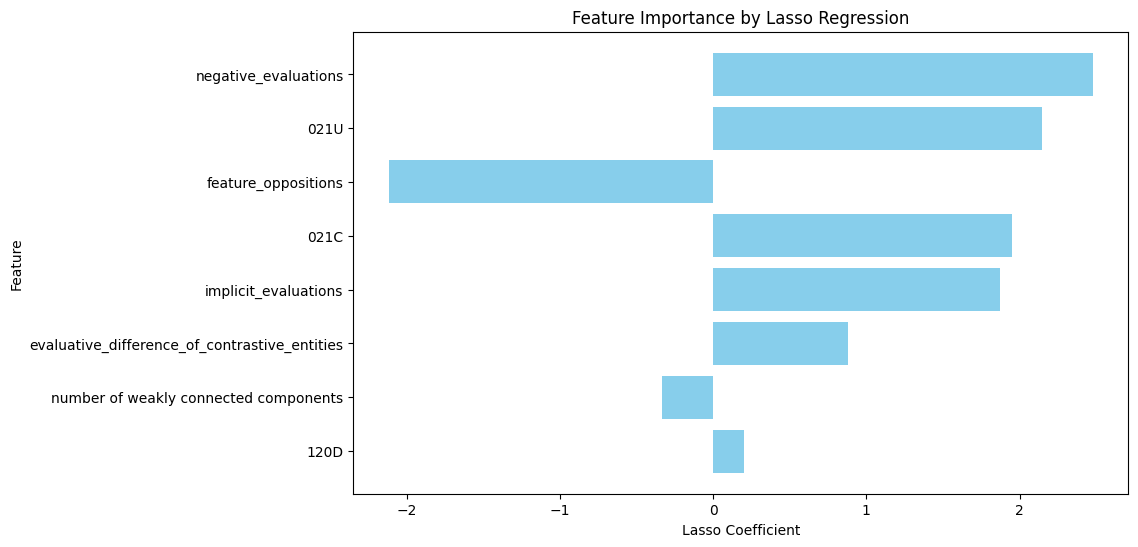

In [199]:
from sklearn.linear_model import LassoCV
import pandas as pd
import numpy as np

# Assuming X and y are already defined and cleaned
# Independent variables (all columns except the dependent variable)
X = lasso_df.drop(columns=['assertive_force_mean', "assertive_clarity_mean", "file",	"Document_title"])
y = lasso_df['assertive_force_mean']

# Lasso Regression with Cross-Validation to tune alpha (regularization strength)
lasso = LassoCV(cv=5, max_iter=15000, alphas=np.logspace(-2, 1, 50), random_state=42).fit(X, y)

# Extract feature coefficients
lasso_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})

# Filter out features with zero coefficients
selected_features = lasso_coefficients[lasso_coefficients['Coefficient'] != 0]

# Sort features by absolute coefficient values
selected_features = selected_features.sort_values(by='Coefficient', key=np.abs, ascending=False)

# Display selected features
print("Selected Features:\n", selected_features)

# Plot the coefficients for visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(selected_features['Feature'], selected_features['Coefficient'], color='skyblue')
plt.xlabel('Lasso Coefficient')
plt.ylabel('Feature')
plt.title('Feature Importance by Lasso Regression')
plt.gca().invert_yaxis()
plt.show()


## hierarchical

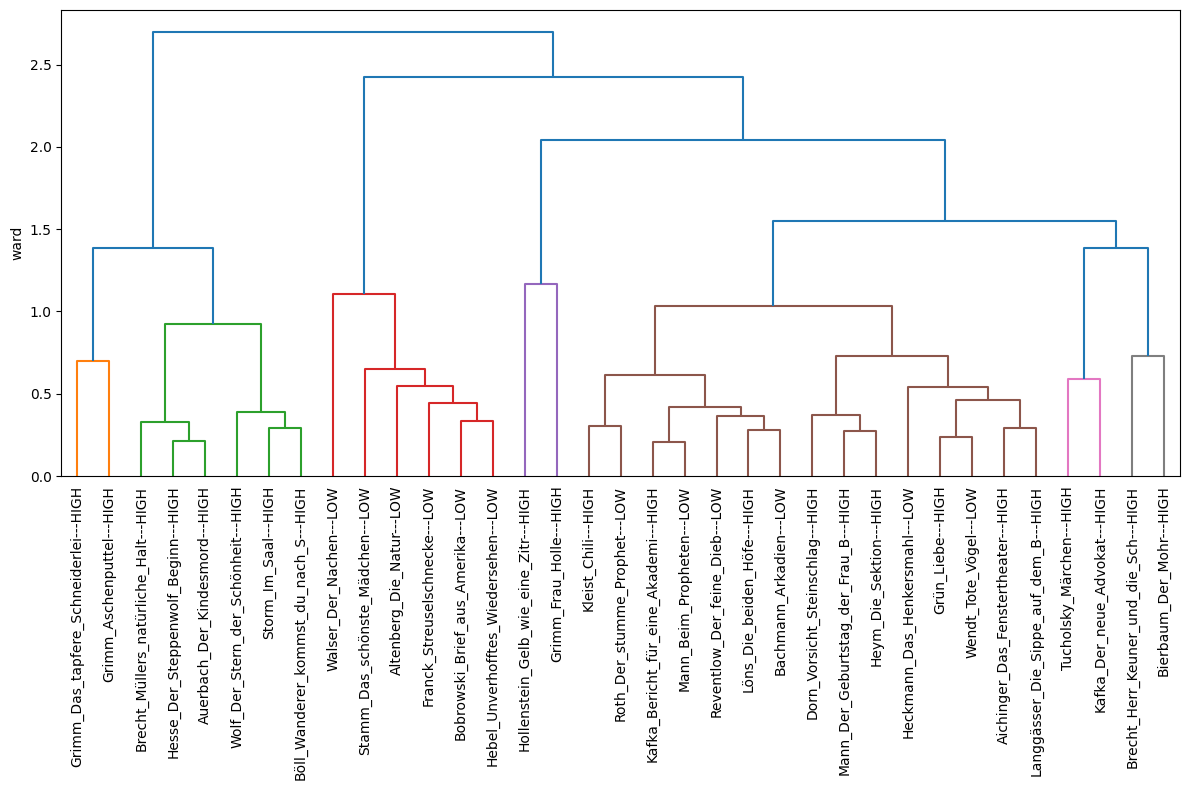

In [200]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Step 1: Extract data based on selected features
selected_feature_names = selected_features['Feature'].tolist()  # From Lasso step
X_selected = X[selected_feature_names]

# Step 2: Standardize the data (a second time?)
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X_selected)

# Step 3: Compute linkage matrix for hierarchical clustering
# You can use different methods for linkage: 'ward', 'single', 'complete', 'average'
linkage_matrix = linkage(X_selected, method='ward')

# Step 4: Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=file_labels.to_list(), leaf_rotation=90, leaf_font_size=10, color_threshold=1.3)
#plt.title("Hierarchical Clustering Dendrogram")
#plt.xlabel("Text Labels")
plt.ylabel("ward")
plt.tight_layout()
plt.savefig(f'dendrogramm_mixed_features_assertive_force.jpg', dpi=1000, facecolor='white')
plt.show()

# Step 5: Extract cluster labels
# Choose the number of clusters using a threshold on the dendrogram
num_clusters = 7  # Adjust as needed
cluster_labels = fcluster(linkage_matrix, t=num_clusters, criterion='maxclust')

# Map cluster labels to text labels
clustered_data = pd.DataFrame({
    'Text_Label': file_labels,
    'Cluster_Label': cluster_labels
})

#print(clustered_data.sort_values(by='Cluster_Label'))


In [201]:
from sklearn.metrics import silhouette_score

# Silhouette score
silhouette_avg = silhouette_score(X_selected, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.3041842242874726


In [202]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

best_score = -1
best_k = 2
for k in range(2, 10):
    labels = fcluster(linkage_matrix, k, criterion='maxclust')

    score = silhouette_score(X_selected, labels)
    print(f"Clusters: {k}, Silhouette Score: {score}")
    if score > best_score:
        best_score = score
        best_k = k

print(f"Optimal clusters: {best_k} with silhouette score: {best_score}")


Clusters: 2, Silhouette Score: 0.23949158011738245
Clusters: 3, Silhouette Score: 0.26730145687561374
Clusters: 4, Silhouette Score: 0.2924668112758611
Clusters: 5, Silhouette Score: 0.2798150133728583
Clusters: 6, Silhouette Score: 0.2948872257685461
Clusters: 7, Silhouette Score: 0.3041842242874726
Clusters: 8, Silhouette Score: 0.3016457865726901
Clusters: 9, Silhouette Score: 0.3011156651552703
Optimal clusters: 7 with silhouette score: 0.3041842242874726


/tmp/ipython-input-203-3739855676.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected['Cluster_Label'] = cluster_labels


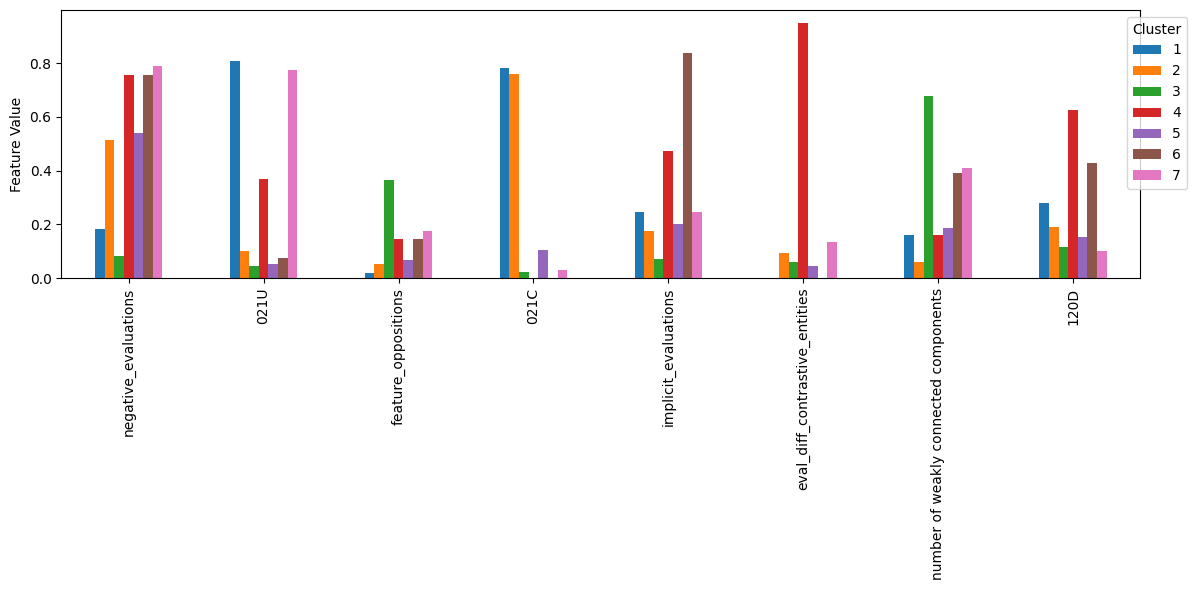

'\n# Heatmap of feature averages by cluster\nsns.heatmap(summary, annot=True, cmap=\'coolwarm\', fmt=".2f")\nplt.tight_layout()\nplt.savefig(f\'heatmap_mixed_features_assertive_clarity.jpg\', dpi=1000, facecolor=\'white\')\nplt.title(\'Feature Heatmap by Cluster\')\nplt.show()\n\n# Boxplots for target variable by cluster\nsns.boxplot(x=cluster_labels, y=y)\nplt.title(\'Target Variable Distribution by Cluster\')\nplt.xlabel(\'Cluster\')\nplt.ylabel(\'Target Variable\')\nplt.show()\n\n# PCA for cluster visualization\npca = PCA(n_components=2)\nX_pca = pca.fit_transform(X_selected.drop(\'Cluster_Label\', axis=1))\nplt.figure(figsize=(10, 7))\nsns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette=\'Set1\')\nplt.title(\'Clusters in PCA-Reduced Feature Space\')\nplt.xlabel(\'PCA Component 1\')\nplt.ylabel(\'PCA Component 2\')\nplt.legend(title=\'Cluster\')\nplt.show()\n\n# Feature importance for predicting clusters\nclf = DecisionTreeClassifier(max_depth=3)\nclf.fit(X_sel

In [203]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

# Split the Document_title column instead of the index
true_labels_df = file_labels.str.split('---', n=1, expand=True)
true_labels_df.columns = ['base_name', 'true_label']

# Merge cluster labels, selected features, and target variable
clustered_data = pd.DataFrame({
    'Text_Label': true_labels_df["base_name"].tolist(),
    'Cluster_Label': cluster_labels
})
X_selected['Cluster_Label'] = cluster_labels
summary = X_selected.groupby('Cluster_Label').mean()
summary_y = pd.concat([y, pd.Series(cluster_labels, name='Cluster_Label')], axis=1).groupby('Cluster_Label').mean()

summary = summary.rename(columns={"evaluative_difference_of_contrastive_entities": "eval_diff_contrastive_entities"})



# Plot feature averages by cluster
summary.T.plot(kind='bar', figsize=(12, 6))
#plt.title('Average Feature Values by Cluster')
plt.ylabel('Feature Value')
#plt.xlabel('Feature')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(f'average_feature_values_mixed_features_assertive_force.jpg', dpi=1000, facecolor='white')
plt.show()

"""
# Heatmap of feature averages by cluster
sns.heatmap(summary, annot=True, cmap='coolwarm', fmt=".2f")
plt.tight_layout()
plt.savefig(f'heatmap_mixed_features_assertive_clarity.jpg', dpi=1000, facecolor='white')
plt.title('Feature Heatmap by Cluster')
plt.show()

# Boxplots for target variable by cluster
sns.boxplot(x=cluster_labels, y=y)
plt.title('Target Variable Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Target Variable')
plt.show()

# PCA for cluster visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_selected.drop('Cluster_Label', axis=1))
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='Set1')
plt.title('Clusters in PCA-Reduced Feature Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

# Feature importance for predicting clusters
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_selected.drop('Cluster_Label', axis=1), cluster_labels)
importances = pd.Series(clf.feature_importances_, index=X_selected.columns[:-1])
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5))
plt.title('Feature Importances for Cluster Prediction')
plt.show()
"""

In [204]:
clustered_data

,Text_Label,Cluster_Label
0,Mann_Der_Geburtstag_der_Frau_B,5
1,Storm_Im_Saal,2
2,Aichinger_Das_Fenstertheater,5
3,Bobrowski_Brief_aus_Amerika,3
4,Hebel_Unverhofftes_Wiedersehen,3
5,Grün_Liebe,5
6,Brecht_Herr_Keuner_und_die_Sch,7
7,Altenberg_Die_Natur,3
8,Böll_Wanderer_kommst_du_nach_S,2
9,Grimm_Das_tapfere_Schneiderlei,1


## Eval F-score

In [205]:
# Split the Document_title column instead of the index
true_labels_df = file_labels.str.split('---', n=1, expand=True)
true_labels_df.columns = ['base_name', 'true_label']

true_labels_df

,base_name,true_label
0,Mann_Der_Geburtstag_der_Frau_B,HIGH
1,Storm_Im_Saal,HIGH
2,Aichinger_Das_Fenstertheater,HIGH
3,Bobrowski_Brief_aus_Amerika,LOW
4,Hebel_Unverhofftes_Wiedersehen,LOW
5,Grün_Liebe,HIGH
6,Brecht_Herr_Keuner_und_die_Sch,HIGH
7,Altenberg_Die_Natur,LOW
8,Böll_Wanderer_kommst_du_nach_S,HIGH
9,Grimm_Das_tapfere_Schneiderlei,HIGH


In [206]:
results = clustered_data.copy()
results["network"] = results["Text_Label"].str[:30]
results = results.drop("Text_Label", axis=1)
results["cluster"] = results["Cluster_Label"]
results = results.drop("Cluster_Label", axis=1)

# adapt names
results["network"] = results["network"].apply(lambda x: x.replace("Roth_Der_stumme_Prophet_Fragme", "Roth_Der_stumme_Prophet"))
results["network"] = results["network"].apply(lambda x: x.replace("Kafka_Dere_Advokat_Kolimo", "Kafka_Der_neue_Advokat"))

results





,network,cluster
0,Mann_Der_Geburtstag_der_Frau_B,5
1,Storm_Im_Saal,2
2,Aichinger_Das_Fenstertheater,5
3,Bobrowski_Brief_aus_Amerika,3
4,Hebel_Unverhofftes_Wiedersehen,3
5,Grün_Liebe,5
6,Brecht_Herr_Keuner_und_die_Sch,7
7,Altenberg_Die_Natur,3
8,Böll_Wanderer_kommst_du_nach_S,2
9,Grimm_Das_tapfere_Schneiderlei,1



Per-class metrics:
- LOW (0): Precision = 1.000, Recall = 0.500, F1 = 0.667
- HIGH (1):    Precision = 0.793, Recall = 1.000, F1 = 0.885

Macro F1:    0.776
Weighted F1: 0.810

Classification Report:
              precision    recall  f1-score   support

         LOW       1.00      0.50      0.67        12
        HIGH       0.79      1.00      0.88        23

    accuracy                           0.83        35
   macro avg       0.90      0.75      0.78        35
weighted avg       0.86      0.83      0.81        35


Missing networks analysis:
- In true labels but not in clustering results: 0
- In clustering results but not in true labels: 0


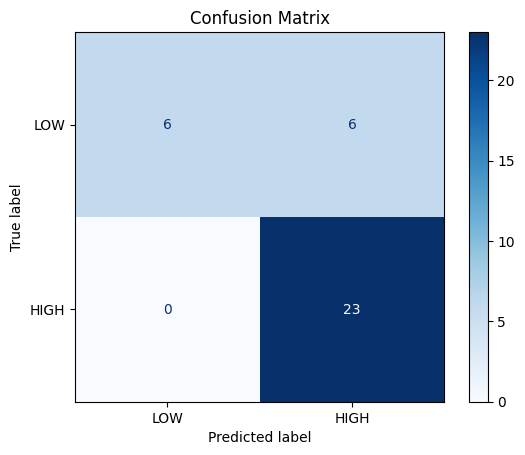

In [207]:
import pandas as pd

import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,  # <-- Add this import
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Assuming:
# - results_df (from clustering) has columns: 'network' and 'cluster'
# - true_labels_df has index 'Document_title' and column 'assertive_force_cat'

# 1. Prepare the dataframes
# Create base_name columns in both dataframes
results_df = results.copy()  # Make sure we're working with a DataFrame
results_df['base_name'] = results_df['network']

# Reset index on true_labels_df to make Document_title a column
#true_labels_df = true_labels_df.reset_index()
#true_labels_df['base_name'] = true_labels_df.index.to_series()
#true_labels_df = true_labels_df.to_frame(name='label')
#true_labels_df['base_name'] = true_labels_df.index.astype(str)
"""
true_labels_df["base_name"] = (
    true_labels_df["base_name"]
    .str.replace(".txt", "", regex=False)
    .str.replace("_neu", "", regex=False)
    .str.replace("_clean", "", regex=False)
    .apply(lambda x: x[:30])  # Truncate to first 30 characters
)
"""

# 2. Merge the dataframes
merged = pd.merge(results_df, true_labels_df,
                 on='base_name',
                 how='inner')

if len(merged) == 0:
    raise ValueError("No matching networks found between clustering results and true labels")

# 3. Label clusters by majority vote
cluster_labels = {}
for cluster in merged['cluster'].unique():
    cluster_df = merged[merged['cluster'] == cluster]
    majority = cluster_df['true_label'].mode()[0]  # Get most frequent label
    cluster_labels[cluster] = majority

# 4. Assign predicted labels
merged['predicted_label'] = merged['cluster'].map(cluster_labels)

# 5. Calculate extended metrics
# Convert labels to binary (if not already done)
label_map = {'HIGH': 1, 'LOW': 0}
merged['true_binary'] = merged['true_label'].map(label_map)
merged['predicted_binary'] = merged['predicted_label'].map(label_map)

# Individual class precision/recall/F1
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    merged['true_binary'],
    merged['predicted_binary'],
    labels=[0, 1]  # LOW (0), HIGH (1)
)

# Macro F1 (unweighted mean across classes)
macro_f1 = f1_score(
    merged['true_binary'],
    merged['predicted_binary'],
    average='macro'
)

# Weighted F1 (weighted by support)
weighted_f1 = f1_score(
    merged['true_binary'],
    merged['predicted_binary'],
    average='weighted'
)

# Print results
print("\nPer-class metrics:")
print(f"- LOW (0): Precision = {precision_per_class[0]:.3f}, Recall = {recall_per_class[0]:.3f}, F1 = {f1_per_class[0]:.3f}")
print(f"- HIGH (1):    Precision = {precision_per_class[1]:.3f}, Recall = {recall_per_class[1]:.3f}, F1 = {f1_per_class[1]:.3f}")
print(f"\nMacro F1:    {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

# Alternative: Full classification report (includes all metrics)
print("\nClassification Report:")
print(classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['LOW', 'HIGH']
))

# 6. Show missing networks (optional)
missing_in_results = set(true_labels_df['base_name']) - set(results_df['base_name'])
missing_in_labels = set(results_df['base_name']) - set(true_labels_df['base_name'])

print("\nMissing networks analysis:")
print(f"- In true labels but not in clustering results: {len(missing_in_results)}")
if missing_in_results:
    print("  Examples:", list(missing_in_results))
print(f"- In clustering results but not in true labels: {len(missing_in_labels)}")
if missing_in_labels:
    print("  Examples:", list(missing_in_labels))

# 7. Confusion matrix (optional)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(merged['true_binary'], merged['predicted_binary'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['LOW', 'HIGH'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [208]:
cluster_df

,network,cluster,base_name,true_label
19,Tucholsky_Märchen,6,Tucholsky_Märchen,HIGH
27,Kafka_Der_neue_Advokat,6,Kafka_Der_neue_Advokat,HIGH


In [209]:
merged

,network,cluster,base_name,true_label,predicted_label,true_binary,predicted_binary
0,Mann_Der_Geburtstag_der_Frau_B,5,Mann_Der_Geburtstag_der_Frau_B,HIGH,HIGH,1,1
1,Storm_Im_Saal,2,Storm_Im_Saal,HIGH,HIGH,1,1
2,Aichinger_Das_Fenstertheater,5,Aichinger_Das_Fenstertheater,HIGH,HIGH,1,1
3,Bobrowski_Brief_aus_Amerika,3,Bobrowski_Brief_aus_Amerika,LOW,LOW,0,0
4,Hebel_Unverhofftes_Wiedersehen,3,Hebel_Unverhofftes_Wiedersehen,LOW,LOW,0,0
5,Grün_Liebe,5,Grün_Liebe,HIGH,HIGH,1,1
6,Brecht_Herr_Keuner_und_die_Sch,7,Brecht_Herr_Keuner_und_die_Sch,HIGH,HIGH,1,1
7,Altenberg_Die_Natur,3,Altenberg_Die_Natur,LOW,LOW,0,0
8,Böll_Wanderer_kommst_du_nach_S,2,Böll_Wanderer_kommst_du_nach_S,HIGH,HIGH,1,1
9,Grimm_Das_tapfere_Schneiderlei,1,Grimm_Das_tapfere_Schneiderlei,HIGH,HIGH,1,1


In [210]:
# Generate the classification report as a string
report_str = classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['LOW', 'HIGH'],
    output_dict=False  # This returns a string
)

# Convert the string report to a dictionary (which pandas can easily convert to DataFrame)
report_dict = classification_report(
    merged['true_binary'],
    merged['predicted_binary'],
    target_names=['LOW', 'HIGH'],
    output_dict=True  # This returns a dictionary
)

# Convert the dictionary to a DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Save to Excel
report_df.to_excel("mixed_features_assertive_force.xlsx")

print("Classification report saved to 'classification_report.xlsx'")

Classification report saved to 'classification_report.xlsx'


In [211]:
results = clustered_data.copy()
results["network"] = results["Text_Label"]
results = results.drop("Text_Label", axis=1)
results["cluster"] = results["Cluster_Label"]
results = results.drop("Cluster_Label", axis=1)
results



,network,cluster
0,Mann_Der_Geburtstag_der_Frau_B,5
1,Storm_Im_Saal,2
2,Aichinger_Das_Fenstertheater,5
3,Bobrowski_Brief_aus_Amerika,3
4,Hebel_Unverhofftes_Wiedersehen,3
5,Grün_Liebe,5
6,Brecht_Herr_Keuner_und_die_Sch,7
7,Altenberg_Die_Natur,3
8,Böll_Wanderer_kommst_du_nach_S,2
9,Grimm_Das_tapfere_Schneiderlei,1


In [212]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(merged['true_label'], merged['cluster'])
#ari = adjusted_rand_score(merged['assertive_clarity_cat'], merged['cluster'])

print(f"Adjusted Rand Index: {ari:.3f}")
# Interpretation: 1=perfect match, 0=random, negative=worse than random

Adjusted Rand Index: 0.068


In [213]:
merged

,network,cluster,base_name,true_label,predicted_label,true_binary,predicted_binary
0,Mann_Der_Geburtstag_der_Frau_B,5,Mann_Der_Geburtstag_der_Frau_B,HIGH,HIGH,1,1
1,Storm_Im_Saal,2,Storm_Im_Saal,HIGH,HIGH,1,1
2,Aichinger_Das_Fenstertheater,5,Aichinger_Das_Fenstertheater,HIGH,HIGH,1,1
3,Bobrowski_Brief_aus_Amerika,3,Bobrowski_Brief_aus_Amerika,LOW,LOW,0,0
4,Hebel_Unverhofftes_Wiedersehen,3,Hebel_Unverhofftes_Wiedersehen,LOW,LOW,0,0
5,Grün_Liebe,5,Grün_Liebe,HIGH,HIGH,1,1
6,Brecht_Herr_Keuner_und_die_Sch,7,Brecht_Herr_Keuner_und_die_Sch,HIGH,HIGH,1,1
7,Altenberg_Die_Natur,3,Altenberg_Die_Natur,LOW,LOW,0,0
8,Böll_Wanderer_kommst_du_nach_S,2,Böll_Wanderer_kommst_du_nach_S,HIGH,HIGH,1,1
9,Grimm_Das_tapfere_Schneiderlei,1,Grimm_Das_tapfere_Schneiderlei,HIGH,HIGH,1,1


In [214]:
# Count predicted labels per cluster
predicted_counts = merged.groupby('cluster')['predicted_label'].value_counts().unstack(fill_value=0)

print("Predicted counts per cluster:")
print(predicted_counts)

Predicted counts per cluster:
predicted_label  HIGH  LOW
cluster                   
1                   2    0
2                   6    0
3                   0    6
4                   2    0
5                  15    0
6                   2    0
7                   2    0


In [215]:
# Count true labels per cluster
true_label_counts = merged.groupby('cluster')['true_binary'].value_counts().unstack(fill_value=0)

print("true label counts per cluster (0 = LOW, 1 = HIGH):")
print(true_label_counts)

true label counts per cluster (0 = LOW, 1 = HIGH):
true_binary  0  1
cluster          
1            0  2
2            0  6
3            6  0
4            0  2
5            6  9
6            0  2
7            0  2


In [216]:
# Create a new column indicating correct/incorrect classification
merged['correct'] = merged['true_binary'] == merged['predicted_binary']

# Initialize dictionaries to store results
cluster_results = {
    1: {'correct': [], 'incorrect': []},
    2: {'correct': [], 'incorrect': []},
    3: {'correct': [], 'incorrect': []},
    4: {'correct': [], 'incorrect': []},
    5: {'correct': [], 'incorrect': []},
    6: {'correct': [], 'incorrect': []},
    7: {'correct': [], 'incorrect': []}
}



# Iterate through each row and classify
for _, row in merged.iterrows():
    cluster = row['cluster']
    network = row['network']

    if row['correct']:
        cluster_results[cluster]['correct'].append(network)
    else:
        cluster_results[cluster]['incorrect'].append(network)

# Print results
for cluster in sorted(cluster_results.keys()):
    print(f"\nCluster {cluster}:")
    print(f"Correctly classified ({len(cluster_results[cluster]['correct'])}):")
    print(cluster_results[cluster]['correct'])

    print(f"\nIncorrectly classified ({len(cluster_results[cluster]['incorrect'])}):")
    print(cluster_results[cluster]['incorrect'])


Cluster 1:
Correctly classified (2):
['Grimm_Das_tapfere_Schneiderlei', 'Grimm_Aschenputtel']

Incorrectly classified (0):
[]

Cluster 2:
Correctly classified (6):
['Storm_Im_Saal', 'Böll_Wanderer_kommst_du_nach_S', 'Brecht_Müllers_natürliche_Halt', 'Hesse_Der_Steppenwolf_Beginn', 'Auerbach_Der_Kindesmord', 'Wolf_Der_Stern_der_Schönheit']

Incorrectly classified (0):
[]

Cluster 3:
Correctly classified (6):
['Bobrowski_Brief_aus_Amerika', 'Hebel_Unverhofftes_Wiedersehen', 'Altenberg_Die_Natur', 'Franck_Streuselschnecke', 'Walser_Der_Nachen', 'Stamm_Das_schönste_Mädchen']

Incorrectly classified (0):
[]

Cluster 4:
Correctly classified (2):
['Hollenstein_Gelb_wie_eine_Zitr', 'Grimm_Frau_Holle']

Incorrectly classified (0):
[]

Cluster 5:
Correctly classified (9):
['Mann_Der_Geburtstag_der_Frau_B', 'Aichinger_Das_Fenstertheater', 'Grün_Liebe', 'Heym_Die_Sektion', 'Löns_Die_beiden_Höfe', 'Kleist_Chili', 'Kafka_Bericht_für_eine_Akademi', 'Dorn_Vorsicht_Steinschlag', 'Langgässer_Die_Sippe_